# 01 — Data Exploration: Cardiovascular Risk Stratification

Interactive exploratory data analysis for the **CVD Risk Stratification & ED Capacity Planning** project.

This notebook loads the model-ready feature store and drives the reusable EDA modules in `src.eda`:

- `DescriptiveAnalyzer` — summary statistics, categorical breakdowns, missing-value audit
- `EDAVisualizer` — 10 publication-quality figures
- `StatisticalTester` — chi-square, ANOVA / Kruskal-Wallis, point-biserial, Shapiro-Wilk
- `EDAReport` — orchestrates all of the above into a markdown report

All generated artifacts land in `outputs/figures/` and `outputs/reports/`.

In [1]:
import os, sys

# Make the project root importable so `import src.eda` works from notebooks/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
%matplotlib inline

## 1. Load the feature store

In [2]:
from src.eda.common import load_features, load_ed_timeseries, load_ed_visits_raw

df = load_features()
print("Feature store shape:", df.shape)
df.head()

Feature store shape: (10000, 53)


,patient_id,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,ca_vessels,thal,target,risk_level,age_z,resting_bp_z,cholesterol_z,max_heart_rate_z,st_depression_z,ca_vessels_z,cp_0,cp_1,cp_2,cp_3,ecg_0,ecg_1,ecg_2,slope_0,slope_1,slope_2,thal_1,thal_2,thal_3,note_count,mentions_chest_pain,mentions_dyspnea,mentions_diabetes,mentions_smoking,mentions_syncope,avg_note_length,age_group,bp_category,cholesterol_category,comorbidity_index,hr_reserve_ratio,framingham_risk_score,ten_year_cvd_risk_pct,ed_visit_count,ed_avg_los_hours,ed_high_acuity_visits,ed_avg_resources
0,P0000001,51,1,2,92,206,0,0,137,0,1.4,2,0,1,0,Low,-0.3296,-1.8907,0.0092,-0.2020,0.4091,-0.7225,0,0,1,0,1,0,0,0,0,1,1,0,0,3,0,0,0,1,0,28.0,50-59,Normal,Borderline,1,0.811,7.0,15.98,2.0,2.07,0.0,1.00
1,P0000002,69,1,2,119,197,0,2,160,1,1.4,1,1,3,0,Medium,1.7363,-0.0971,-0.3354,0.9742,0.4091,0.3498,0,0,1,0,0,0,1,0,1,0,0,0,1,3,1,1,0,0,0,35.7,60-69,Normal,Desirable,2,1.060,9.0,22.79,3.0,4.65,0.0,6.33
2,P0000003,60,1,0,96,233,0,2,154,0,0.8,0,0,1,0,Low,0.7033,-1.6249,1.0430,0.6674,-0.2515,-0.7225,1,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,33.0,60-69,Normal,Borderline,1,0.962,9.0,22.79,0.0,0.00,0.0,0.00
3,P0000004,56,1,0,151,266,0,2,149,0,0.8,1,0,3,0,Medium,0.2443,2.0287,2.3066,0.4117,-0.2515,-0.7225,1,0,0,0,0,0,1,0,1,0,0,0,1,3,1,0,0,1,0,28.3,50-59,Stage2,High,3,0.909,11.0,31.43,4.0,4.44,0.0,3.75
4,P0000005,45,0,0,120,207,0,0,153,0,1.8,0,0,3,0,Low,-1.0182,-0.0306,0.0475,0.6162,0.8495,-0.7225,1,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,26.0,40-49,Elevated,Borderline,0,0.874,5.0,10.91,0.0,0.00,0.0,0.00


In [3]:
# Column overview
df.dtypes.to_frame("dtype").head(60)

,dtype
patient_id,object
age,int64
sex,int64
chest_pain_type,int64
resting_bp,int64
cholesterol,int64
fasting_blood_sugar,int64
rest_ecg,int64
max_heart_rate,int64
exercise_angina,int64


## 2. Descriptive statistics

In [4]:
from src.eda.descriptive_stats import DescriptiveAnalyzer

analyzer = DescriptiveAnalyzer(df)
numeric_summary = analyzer.numeric_summary()
numeric_summary.round(2)

,count,mean,std,min,q25,median,q75,max,iqr,skewness,kurtosis,cv
feature,,,,,,,,,,,,
age,10000,53.87,8.71,30.00,48.00,54.00,60.00,80.00,12.00,0.04,-0.27,0.16
resting_bp,10000,120.46,15.05,90.00,110.00,120.00,130.25,179.00,20.25,0.15,-0.22,0.12
cholesterol,10000,205.76,26.12,161.00,187.00,200.00,219.00,401.00,32.00,1.31,2.64,0.13
max_heart_rate,10000,140.95,19.55,70.00,128.00,141.00,154.00,210.00,26.00,-0.03,0.00,0.14
st_depression,10000,1.03,0.91,0.00,0.40,0.80,1.40,6.50,1.00,1.72,4.15,0.88
ca_vessels,10000,0.67,0.93,0.00,0.00,0.00,1.00,3.00,1.00,1.19,0.27,1.38
comorbidity_index,10000,1.65,1.13,0.00,1.00,2.00,2.00,6.00,1.00,0.49,-0.07,0.68
hr_reserve_ratio,10000,0.85,0.11,0.46,0.78,0.85,0.92,1.31,0.15,-0.00,0.09,0.13
framingham_risk_score,10000,7.91,2.99,-2.00,6.00,8.00,10.00,20.00,4.00,0.28,-0.01,0.38


In [5]:
# Target (CVD risk level) distribution
target_dist = analyzer.target_distribution()
target_dist

,risk_level,count,proportion,disease_prevalence
0,Low,7168,0.7168,0.1314
1,Medium,1946,0.1946,0.4435
2,High,886,0.0886,0.7472


In [6]:
# Categorical breakdown (first 20 rows)
analyzer.categorical_summary().head(20)

,feature,category,count,proportion
0,sex,Male,6768,0.6768
1,sex,Female,3232,0.3232
2,chest_pain_type,Typical Angina,4635,0.4635
3,chest_pain_type,Non-Anginal,2966,0.2966
4,chest_pain_type,Atypical Angina,1696,0.1696
5,chest_pain_type,Asymptomatic,703,0.0703
6,fasting_blood_sugar,FBS ≤ 120 mg/dl,8464,0.8464
7,fasting_blood_sugar,FBS > 120 mg/dl,1536,0.1536
8,rest_ecg,Normal,4905,0.4905
9,rest_ecg,LV Hypertrophy,4792,0.4792


In [7]:
# Missing-value audit — expect a fully populated feature store
analyzer.missing_audit().head(15)

,column,dtype,missing_count,missing_pct,n_unique
0,patient_id,object,0,0.0,10000
1,age,int64,0,0.0,51
2,sex,int64,0,0.0,2
3,chest_pain_type,int64,0,0.0,4
4,resting_bp,int64,0,0.0,84
5,cholesterol,int64,0,0.0,170
6,fasting_blood_sugar,int64,0,0.0,2
7,rest_ecg,int64,0,0.0,3
8,max_heart_rate,int64,0,0.0,130
9,exercise_angina,int64,0,0.0,2


### Findings — descriptive stats

- The dataset holds 10,000 synthetic patients with a three-level CVD risk target.
- Mean age increases monotonically across Low → Medium → High risk groups.
- The feature store is fully populated (no missing cells), so no imputation is required downstream.

## 3. Statistical hypothesis testing

In [8]:
from src.eda.statistical_tests import StatisticalTester

tester = StatisticalTester(df)
results = tester.run()
results.head(20)

,test,feature,target,statistic,dof,p_value,effect_size,effect_metric,significant,significance,interpretation
0,chi_square,sex,risk_level,140.3900,2,3.271104e-31,0.1176,cramers_v,True,***,NaN
1,chi_square,chest_pain_type,risk_level,65.6446,6,3.185747e-12,0.0546,cramers_v,True,***,NaN
2,chi_square,fasting_blood_sugar,risk_level,155.4901,2,1.720885e-34,0.1239,cramers_v,True,***,NaN
3,chi_square,rest_ecg,risk_level,98.7163,4,1.845407e-20,0.0688,cramers_v,True,***,NaN
4,chi_square,exercise_angina,risk_level,584.1365,2,1.433399e-127,0.2413,cramers_v,True,***,NaN
5,chi_square,st_slope,risk_level,129.4013,4,5.229233e-27,0.0792,cramers_v,True,***,NaN
6,chi_square,thal,risk_level,444.1625,4,7.939714e-95,0.1484,cramers_v,True,***,NaN
7,chi_square,ca_vessels,risk_level,1539.0302,6,0.000000e+00,0.2769,cramers_v,True,***,NaN
8,chi_square,age_group,risk_level,1055.2471,8,1.767214e-222,0.2289,cramers_v,True,***,NaN
9,chi_square,bp_category,risk_level,541.9002,6,7.867402e-114,0.1637,cramers_v,True,***,NaN


In [9]:
# Chi-square: categorical associations with risk level, ranked by effect size
chi = results[results["test"] == "chi_square"].sort_values("effect_size", ascending=False)
chi[["feature", "statistic", "p_value", "effect_size", "significance"]]

,feature,statistic,p_value,effect_size,significance
7,ca_vessels,1539.0302,0.000000e+00,0.2769,***
4,exercise_angina,584.1365,1.433399e-127,0.2413,***
8,age_group,1055.2471,1.767214e-222,0.2289,***
9,bp_category,541.9002,7.867402e-114,0.1637,***
6,thal,444.1625,7.939714e-95,0.1484,***
2,fasting_blood_sugar,155.4901,1.720885e-34,0.1239,***
0,sex,140.3900,3.271104e-31,0.1176,***
10,cholesterol_category,168.1354,2.628016e-35,0.0906,***
5,st_slope,129.4013,5.229233e-27,0.0792,***
3,rest_ecg,98.7163,1.845407e-20,0.0688,***


In [10]:
# Point-biserial: strongest linear correlates of the binary disease target
pb = results[results["test"] == "point_biserial"].copy()
pb["abs_r"] = pb["statistic"].abs()
pb.sort_values("abs_r", ascending=False)[["feature", "statistic", "p_value", "significance"]]

,feature,statistic,p_value,significance
44,ten_year_cvd_risk_pct,0.3355,1.588656e-261,***
45,ed_visit_count,0.3274,1.881767e-248,***
43,framingham_risk_score,0.3255,1.723937e-245,***
46,ed_avg_los_hours,0.3179,1.211341e-233,***
41,comorbidity_index,0.2967,2.050308e-202,***
38,max_heart_rate,-0.2537,1.220048e-146,***
40,ca_vessels,0.2293,2.098066e-119,***
35,age,0.2059,3.365299e-96,***
42,hr_reserve_ratio,-0.1918,1.599904e-83,***
39,st_depression,0.1814,9.262881e-75,***


### Findings — statistical tests

- Exercise-induced angina, thalassemia and fasting blood sugar show the strongest categorical
  associations with risk level (largest Cramér's V, all p < 0.001).
- ST depression, max heart rate and the computed Framingham score are the strongest numeric
  correlates of the disease target.
- Shapiro-Wilk indicates several key numeric features are non-normal, favouring tree-based models.

## 4. Visualisations

Each method saves a 300-DPI figure to `outputs/figures/` and renders inline below.

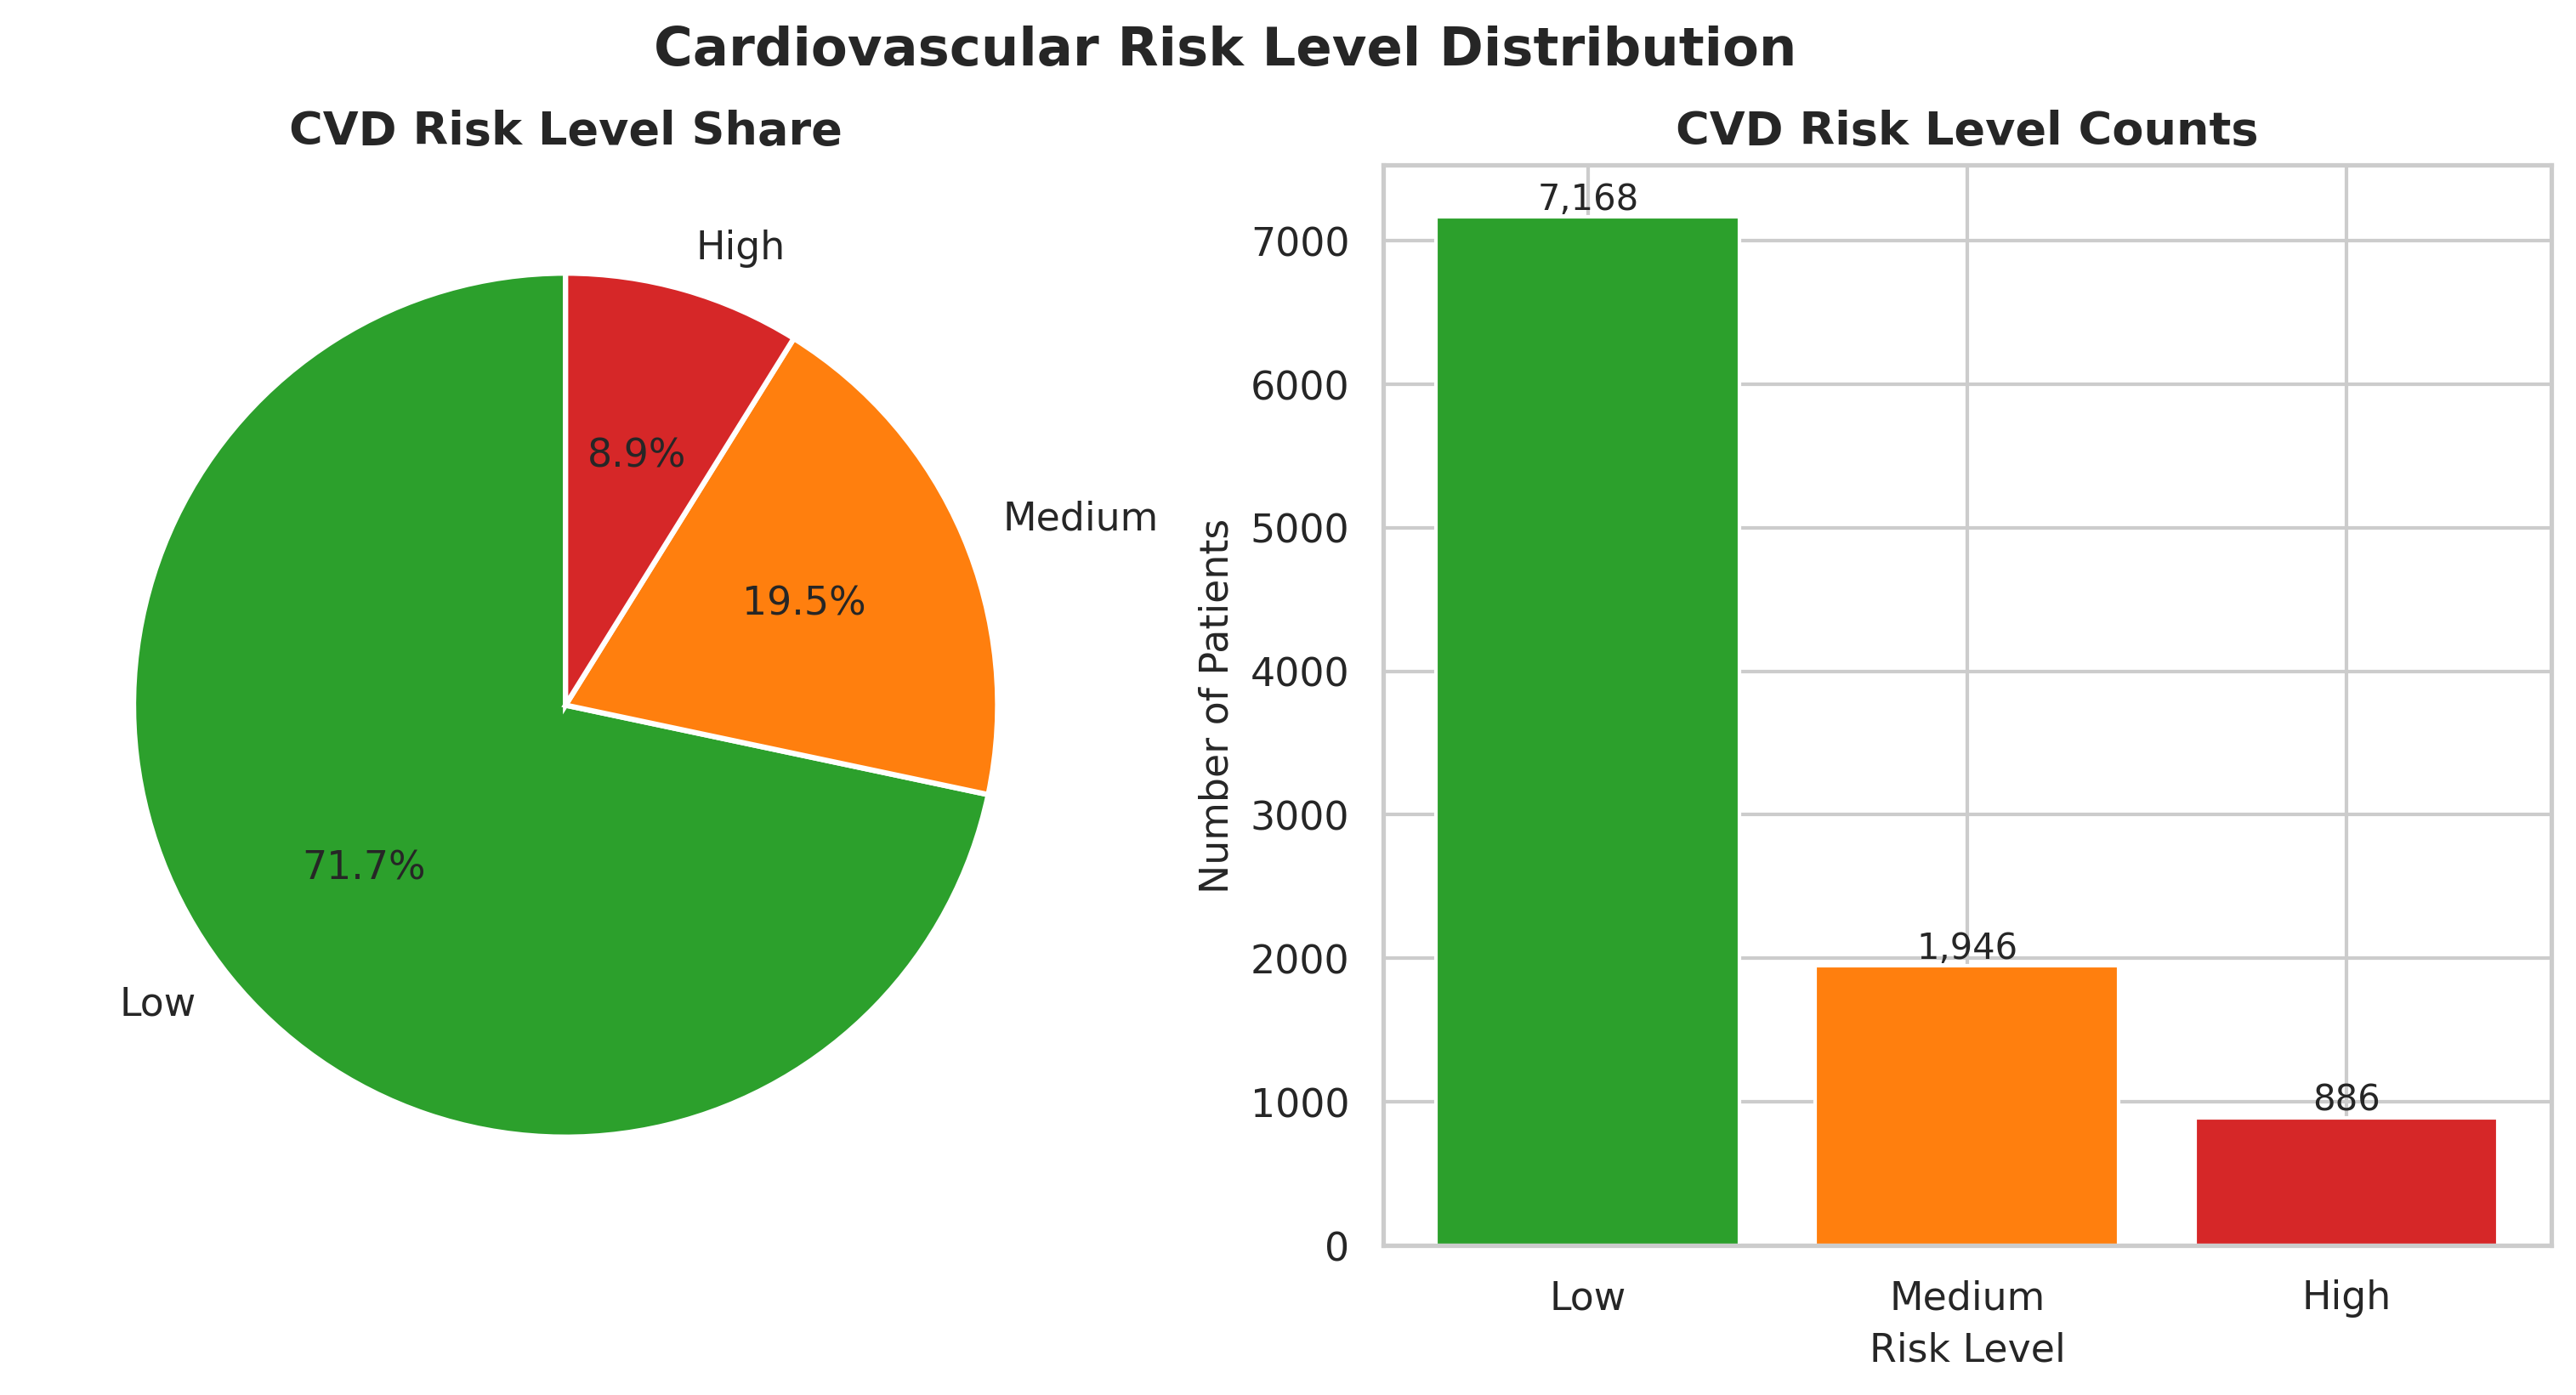

In [11]:
from src.eda.visualizations import EDAVisualizer

viz = EDAVisualizer(df)
path = viz.plot_risk_distribution()
from IPython.display import Image, display
display(Image(filename=path))

### Age group vs risk level

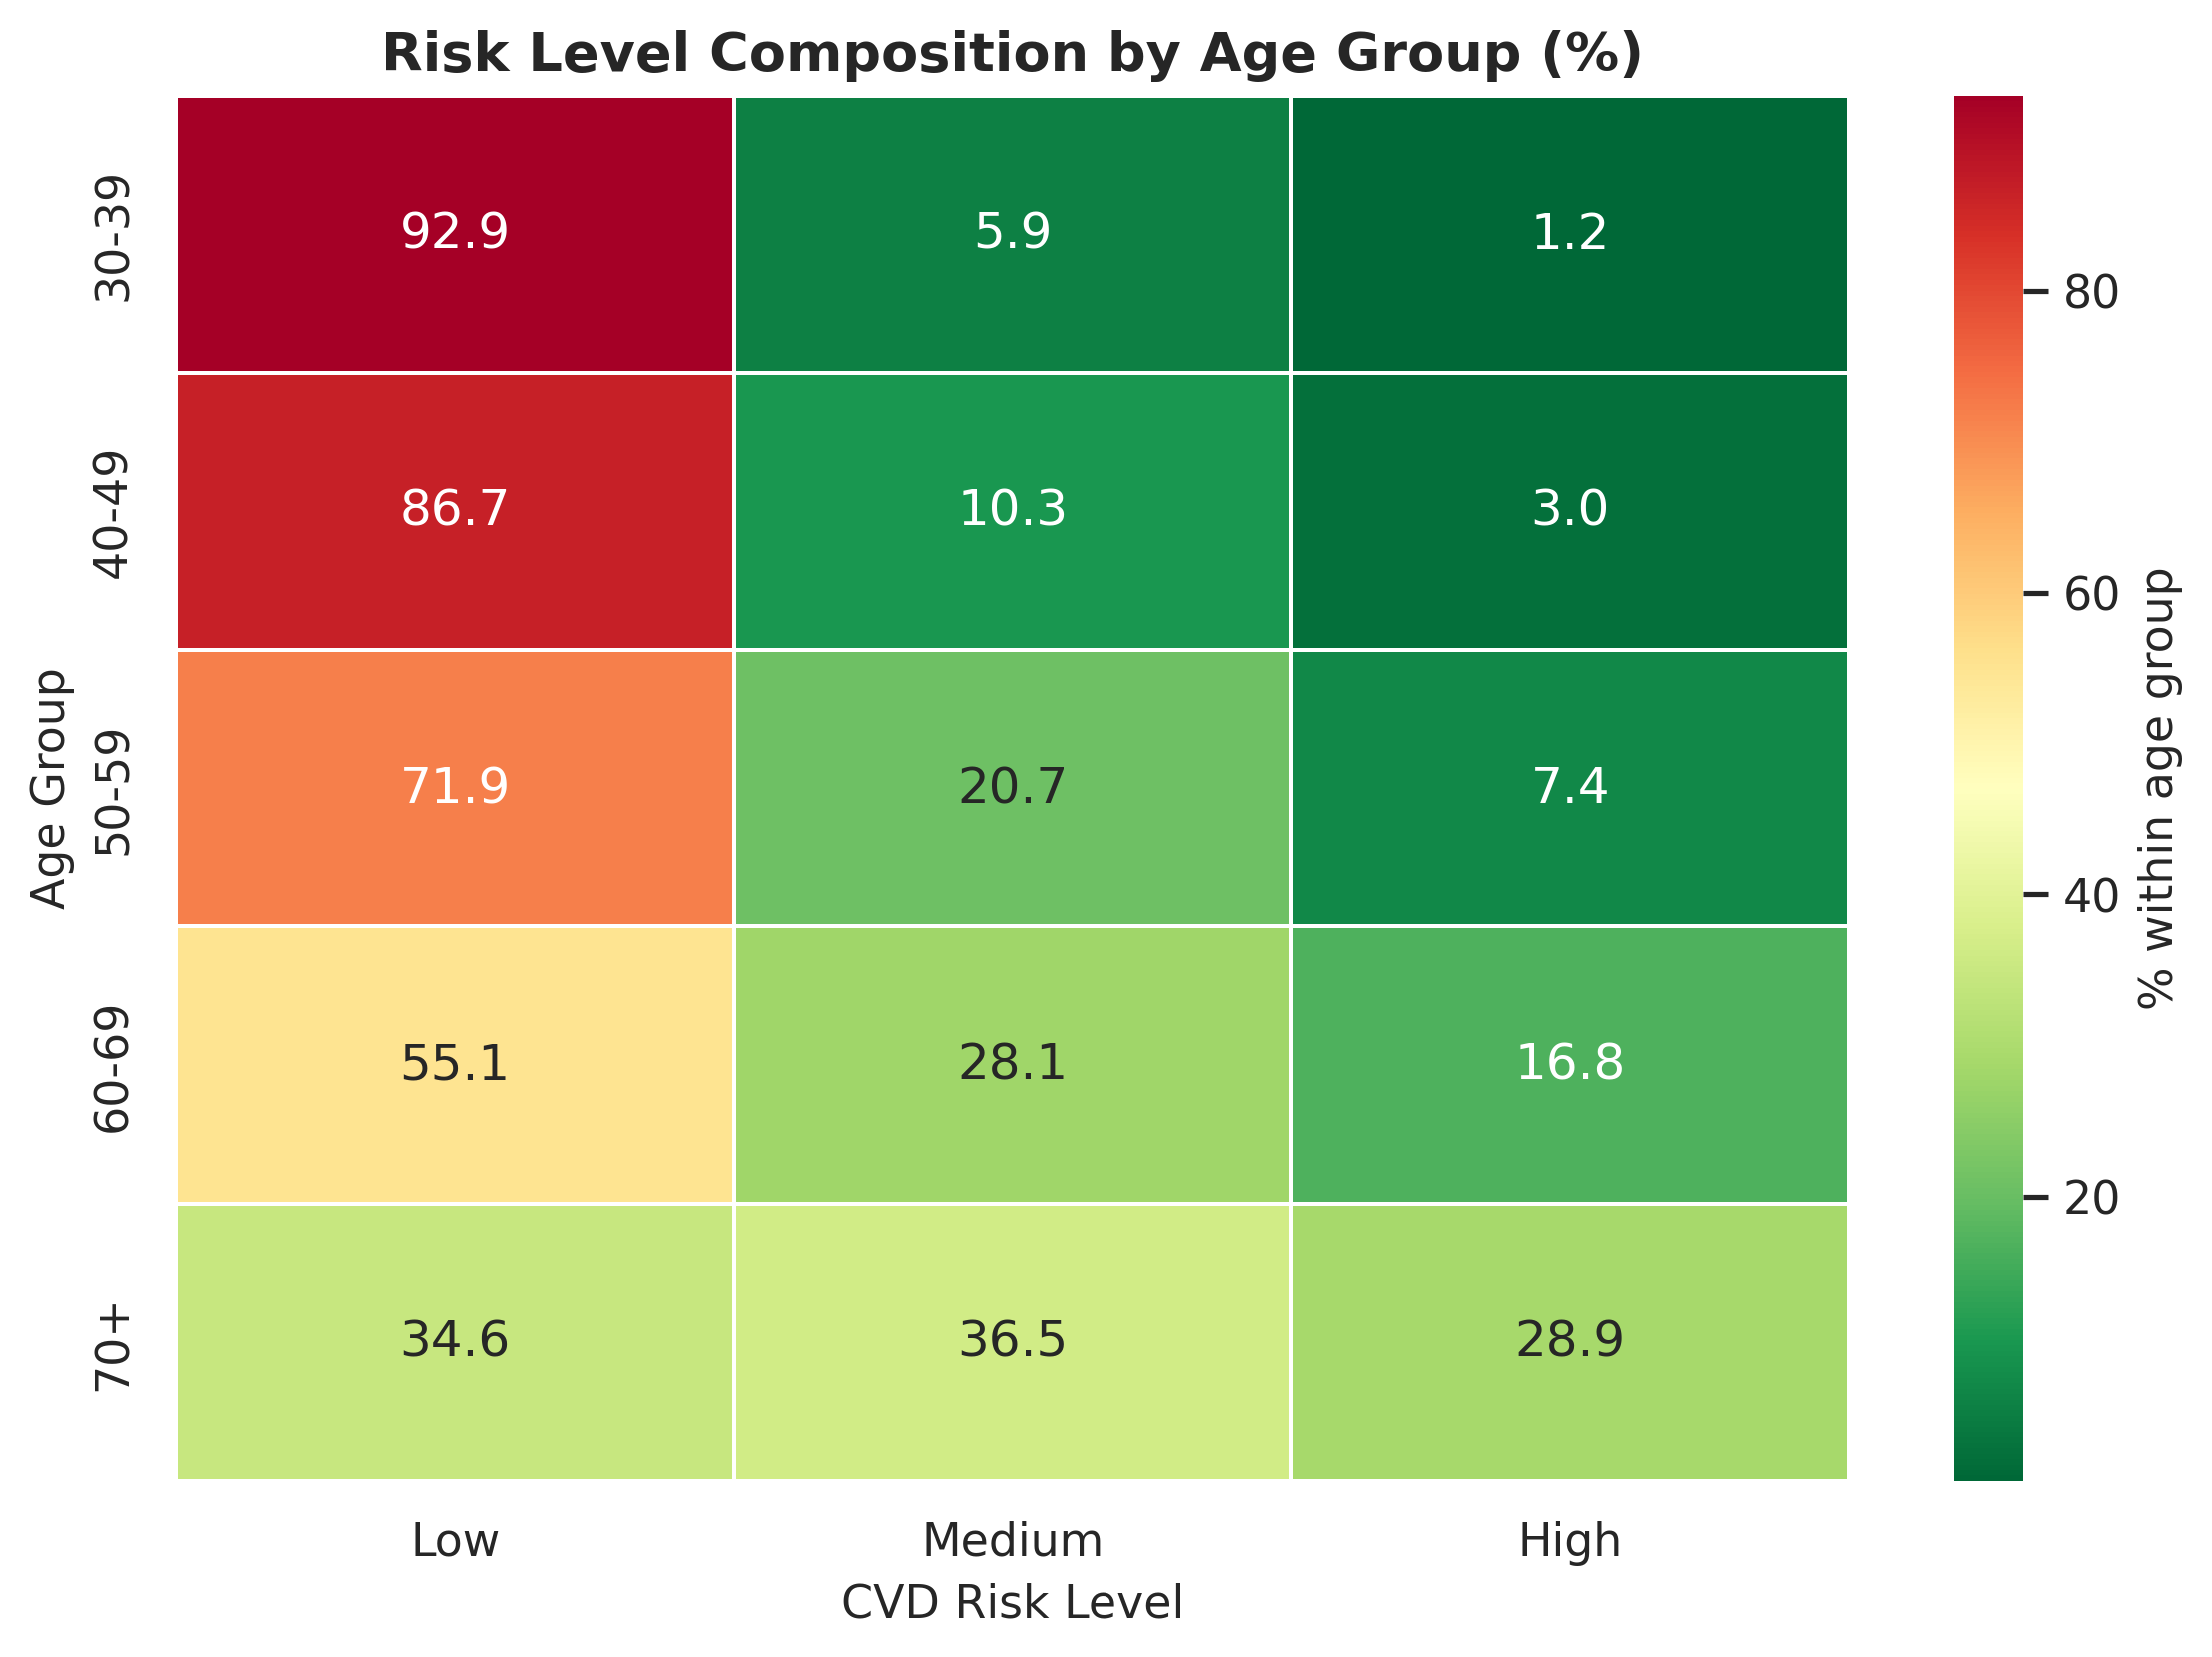

In [12]:
path = viz.plot_age_risk_heatmap()
display(Image(filename=path))

### Correlation heatmap

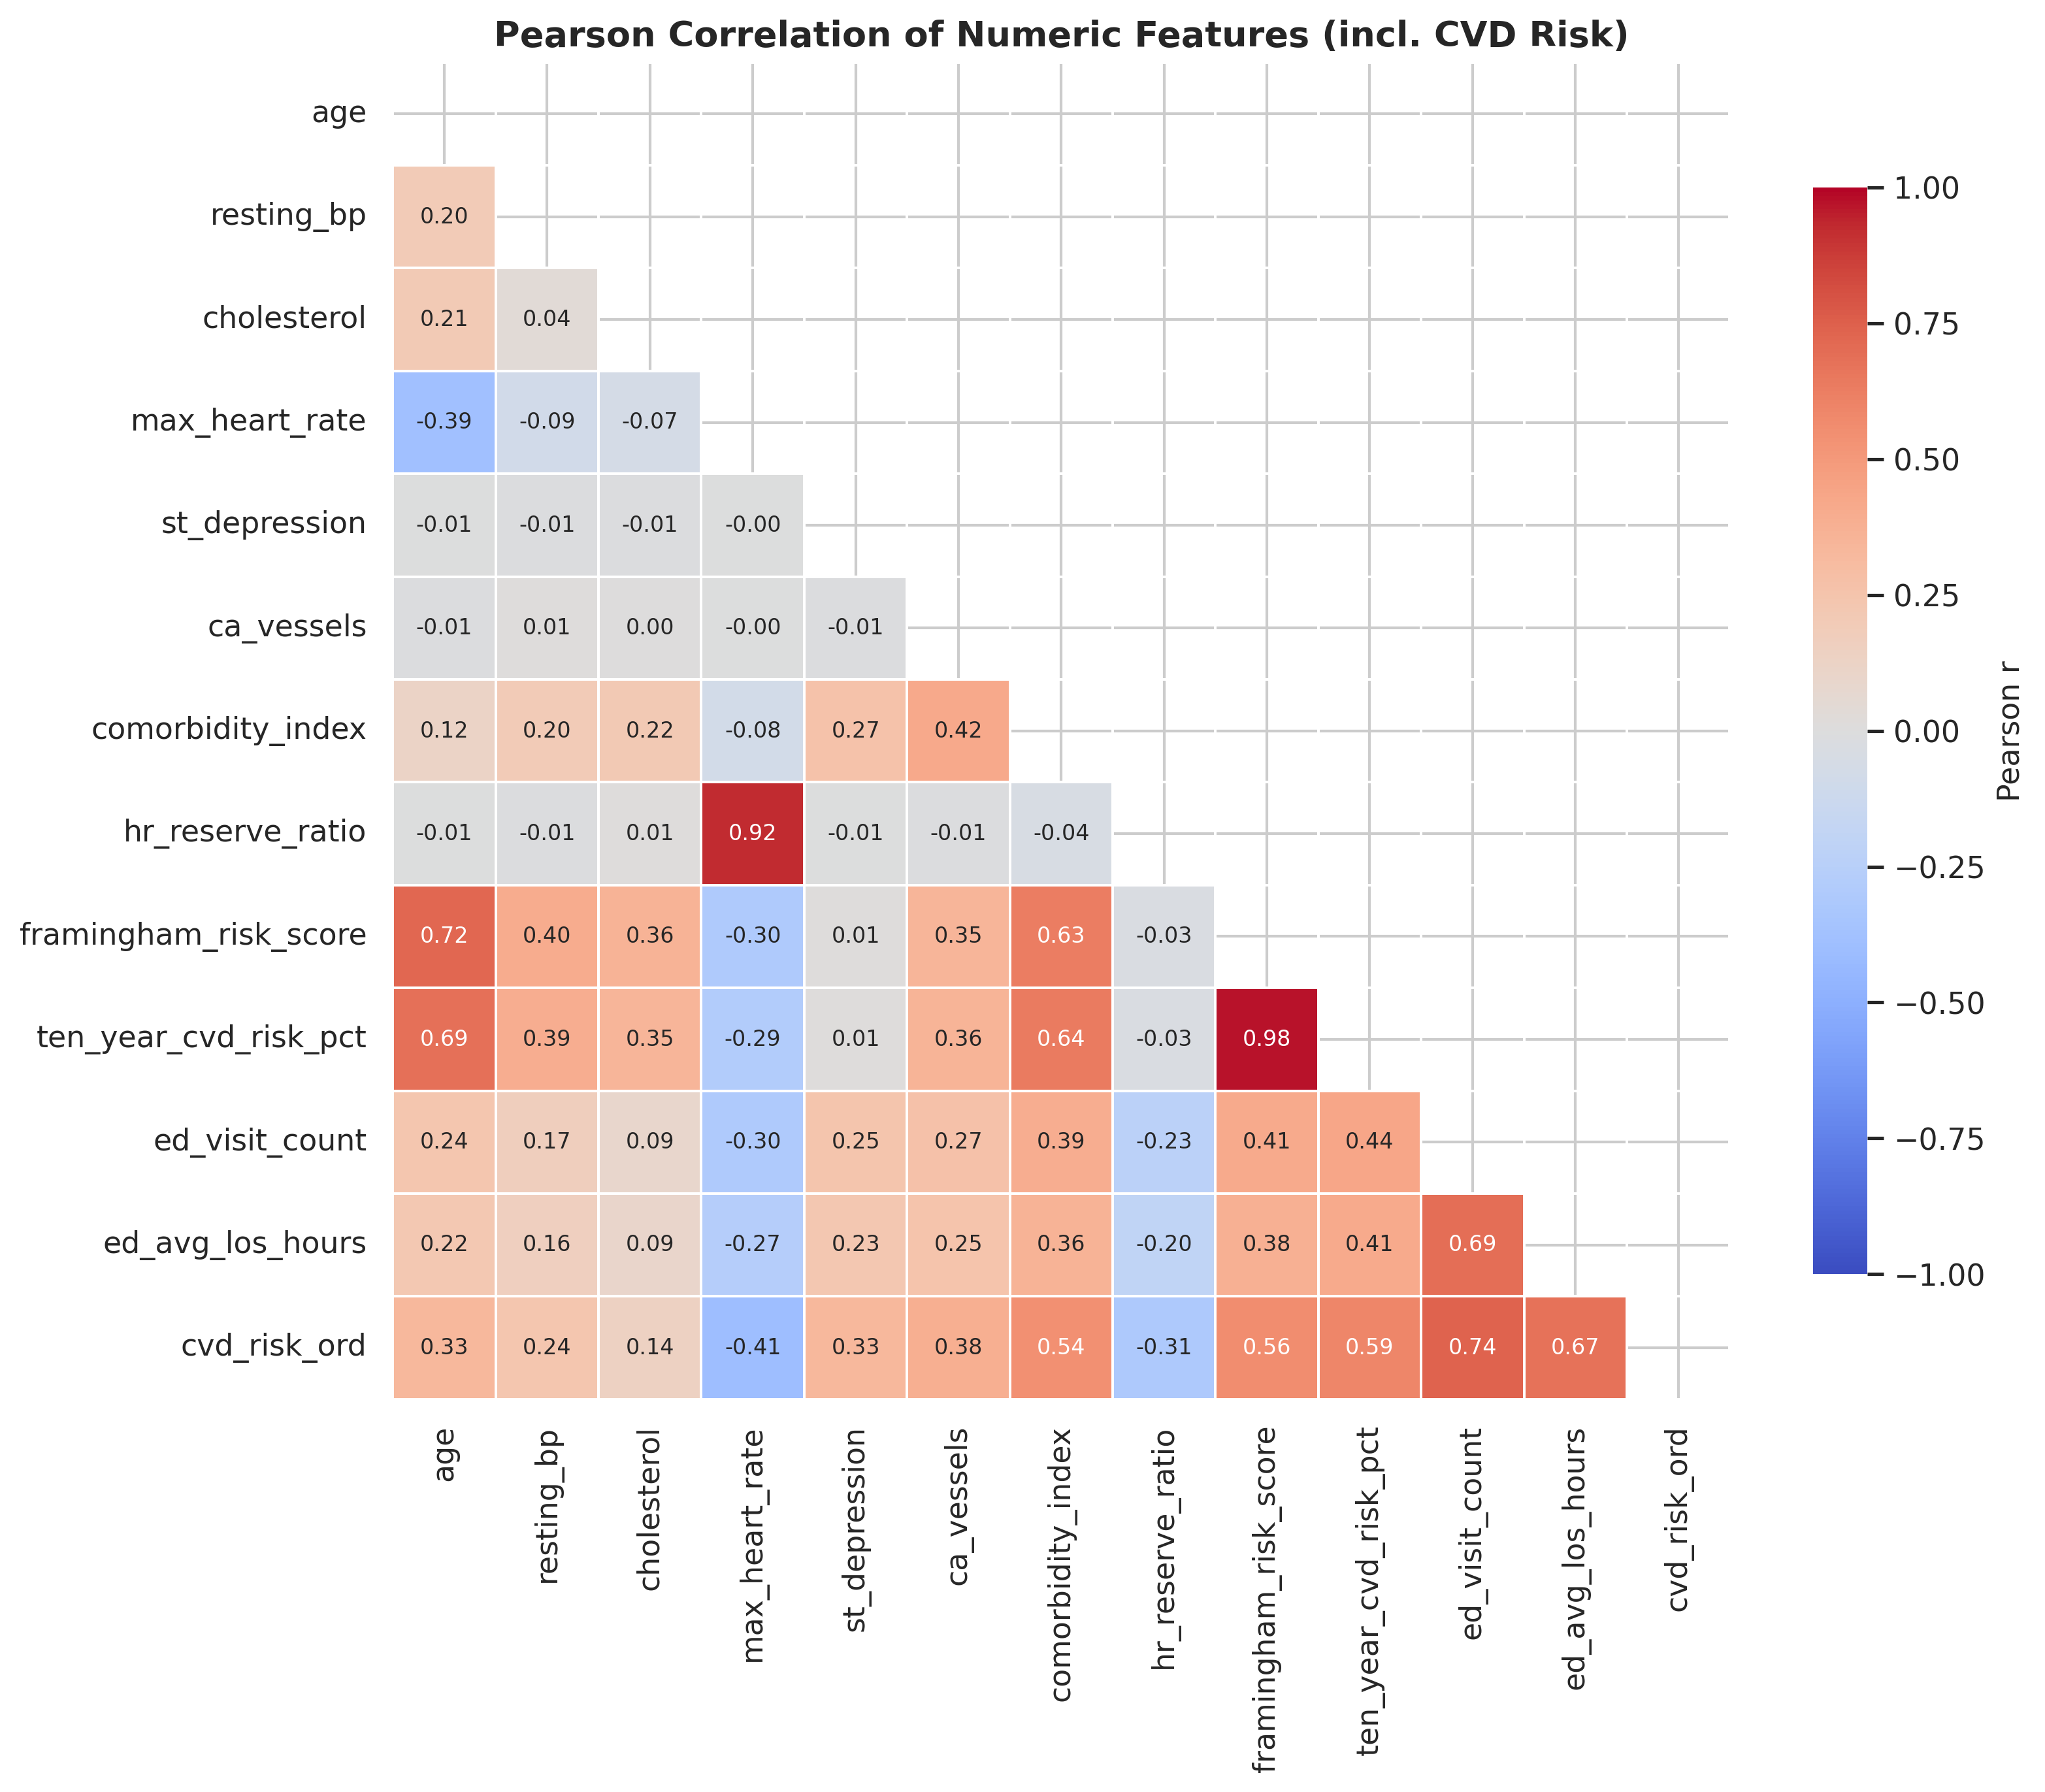

In [13]:
path = viz.plot_correlation_heatmap()
display(Image(filename=path))

### Key feature distributions by risk

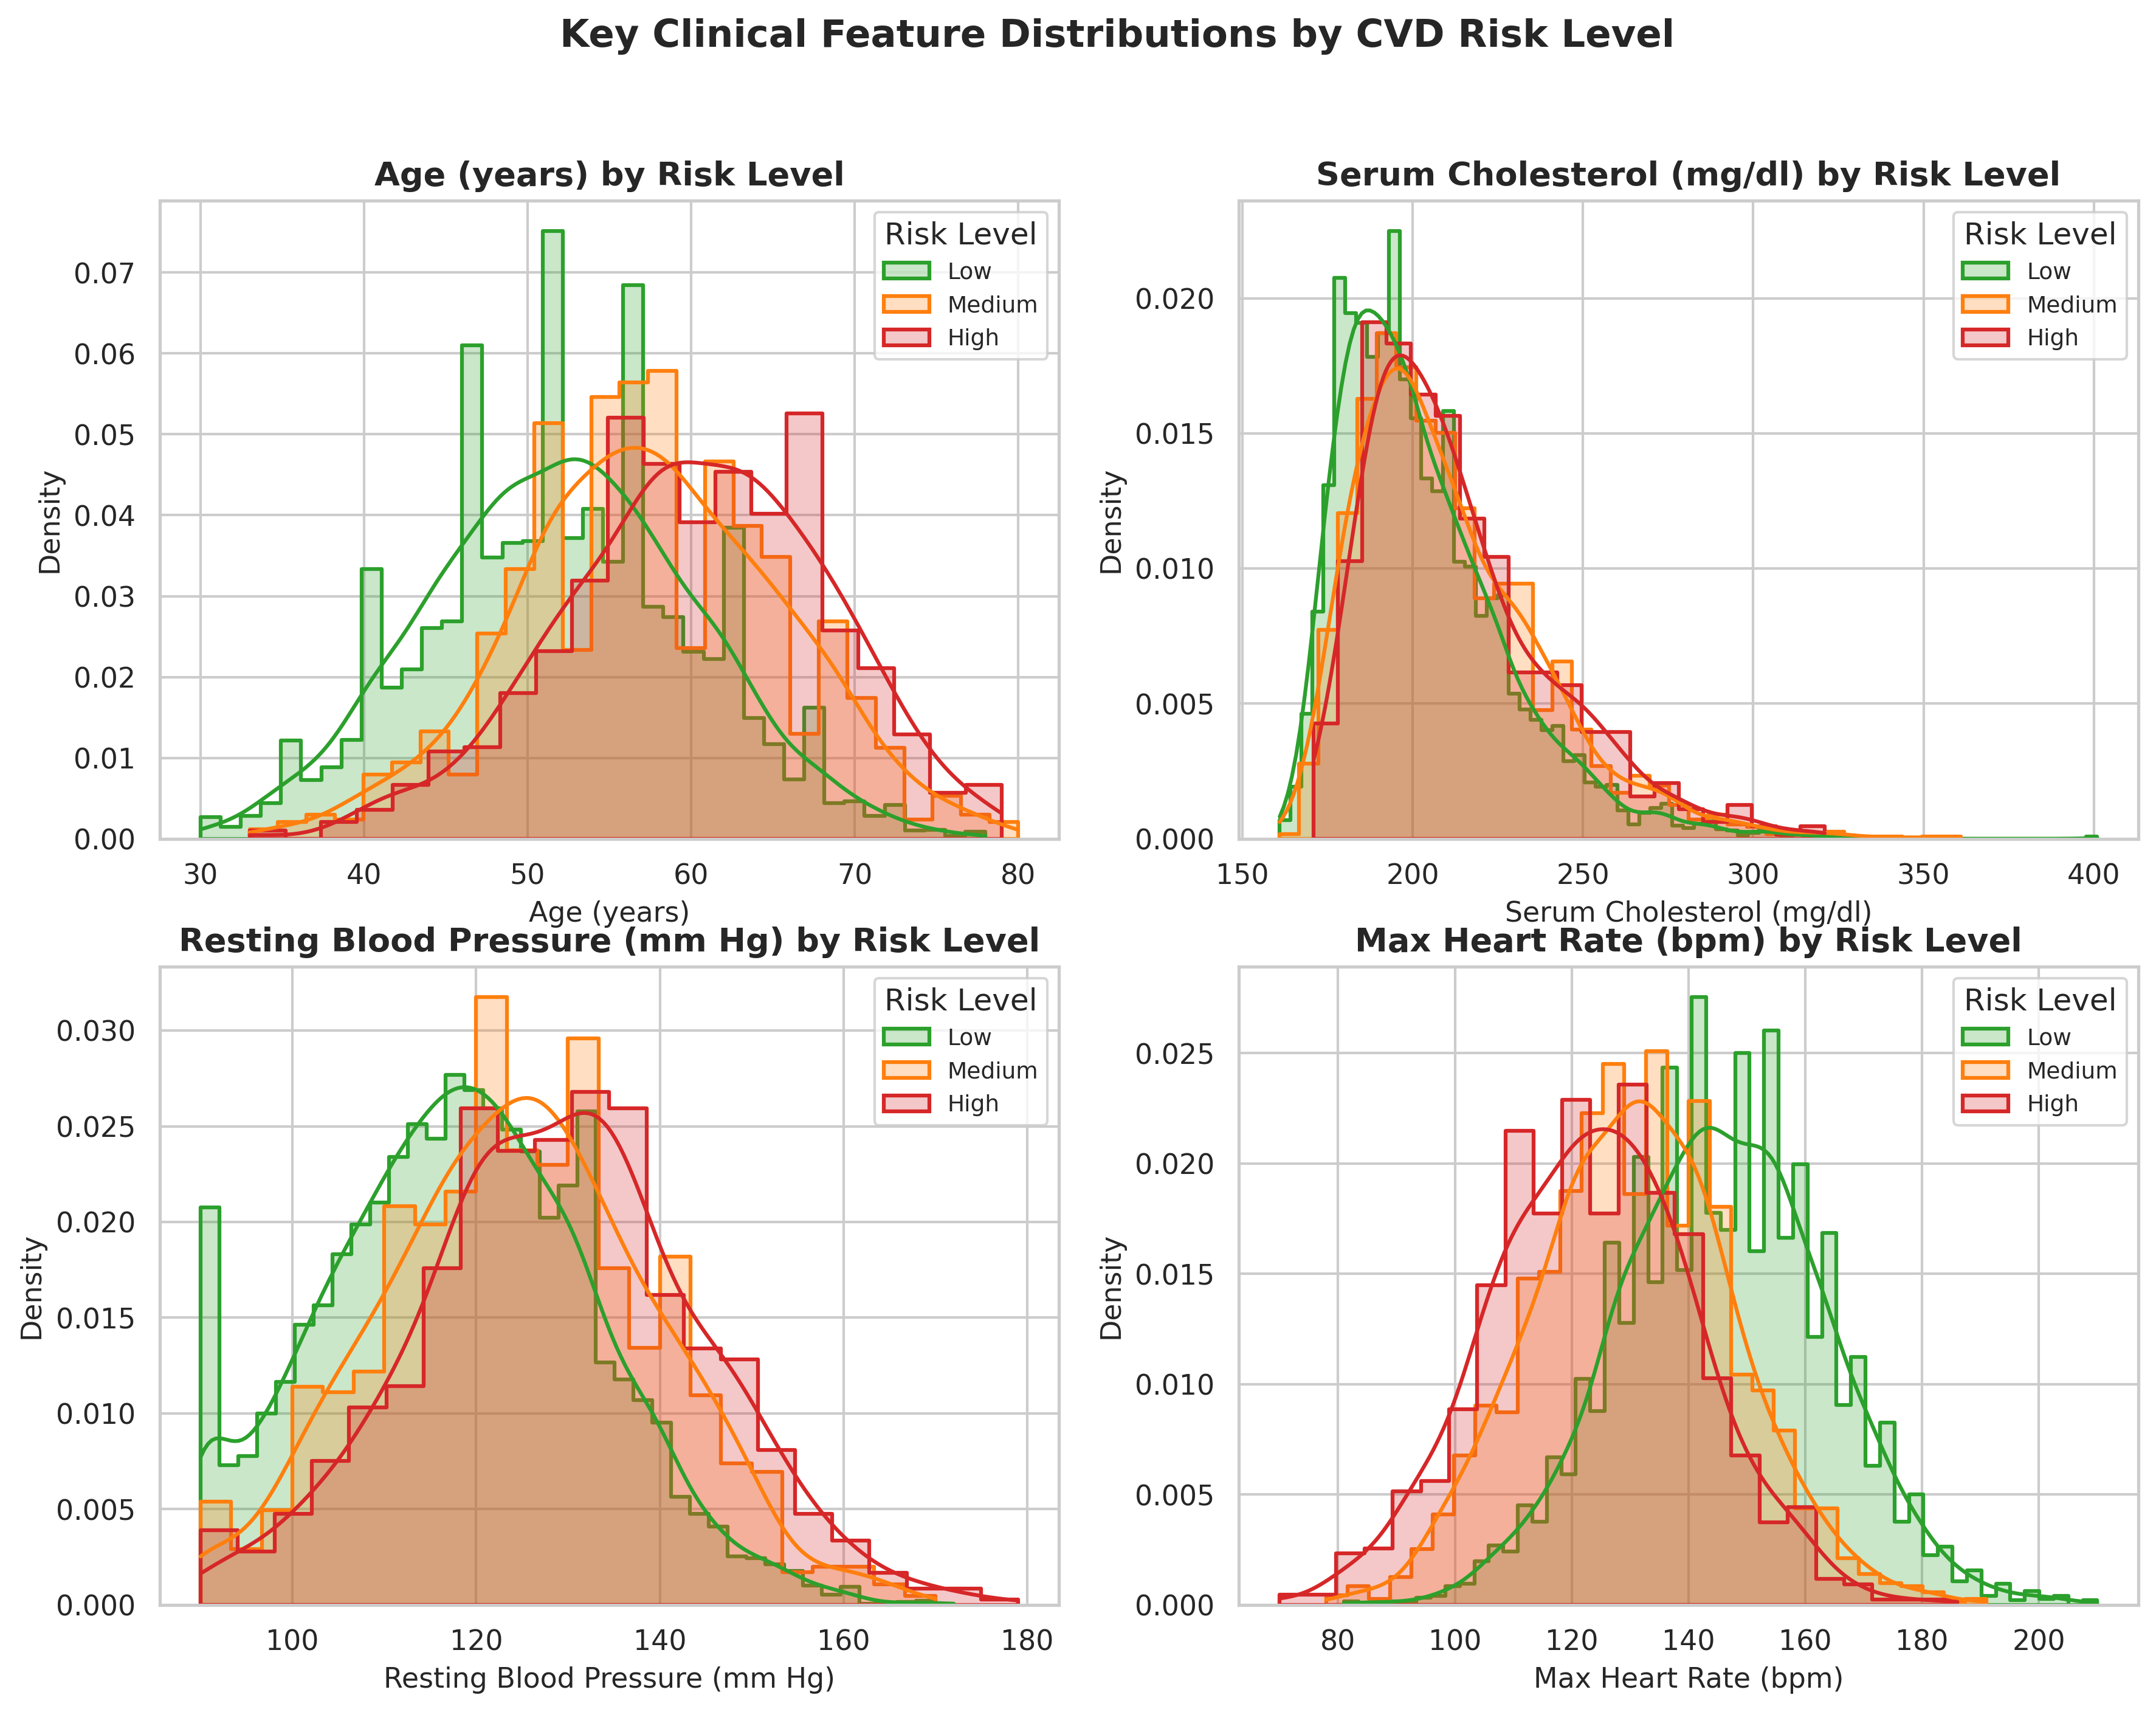

In [14]:
path = viz.plot_feature_distributions()
display(Image(filename=path))

### Risk by demographics

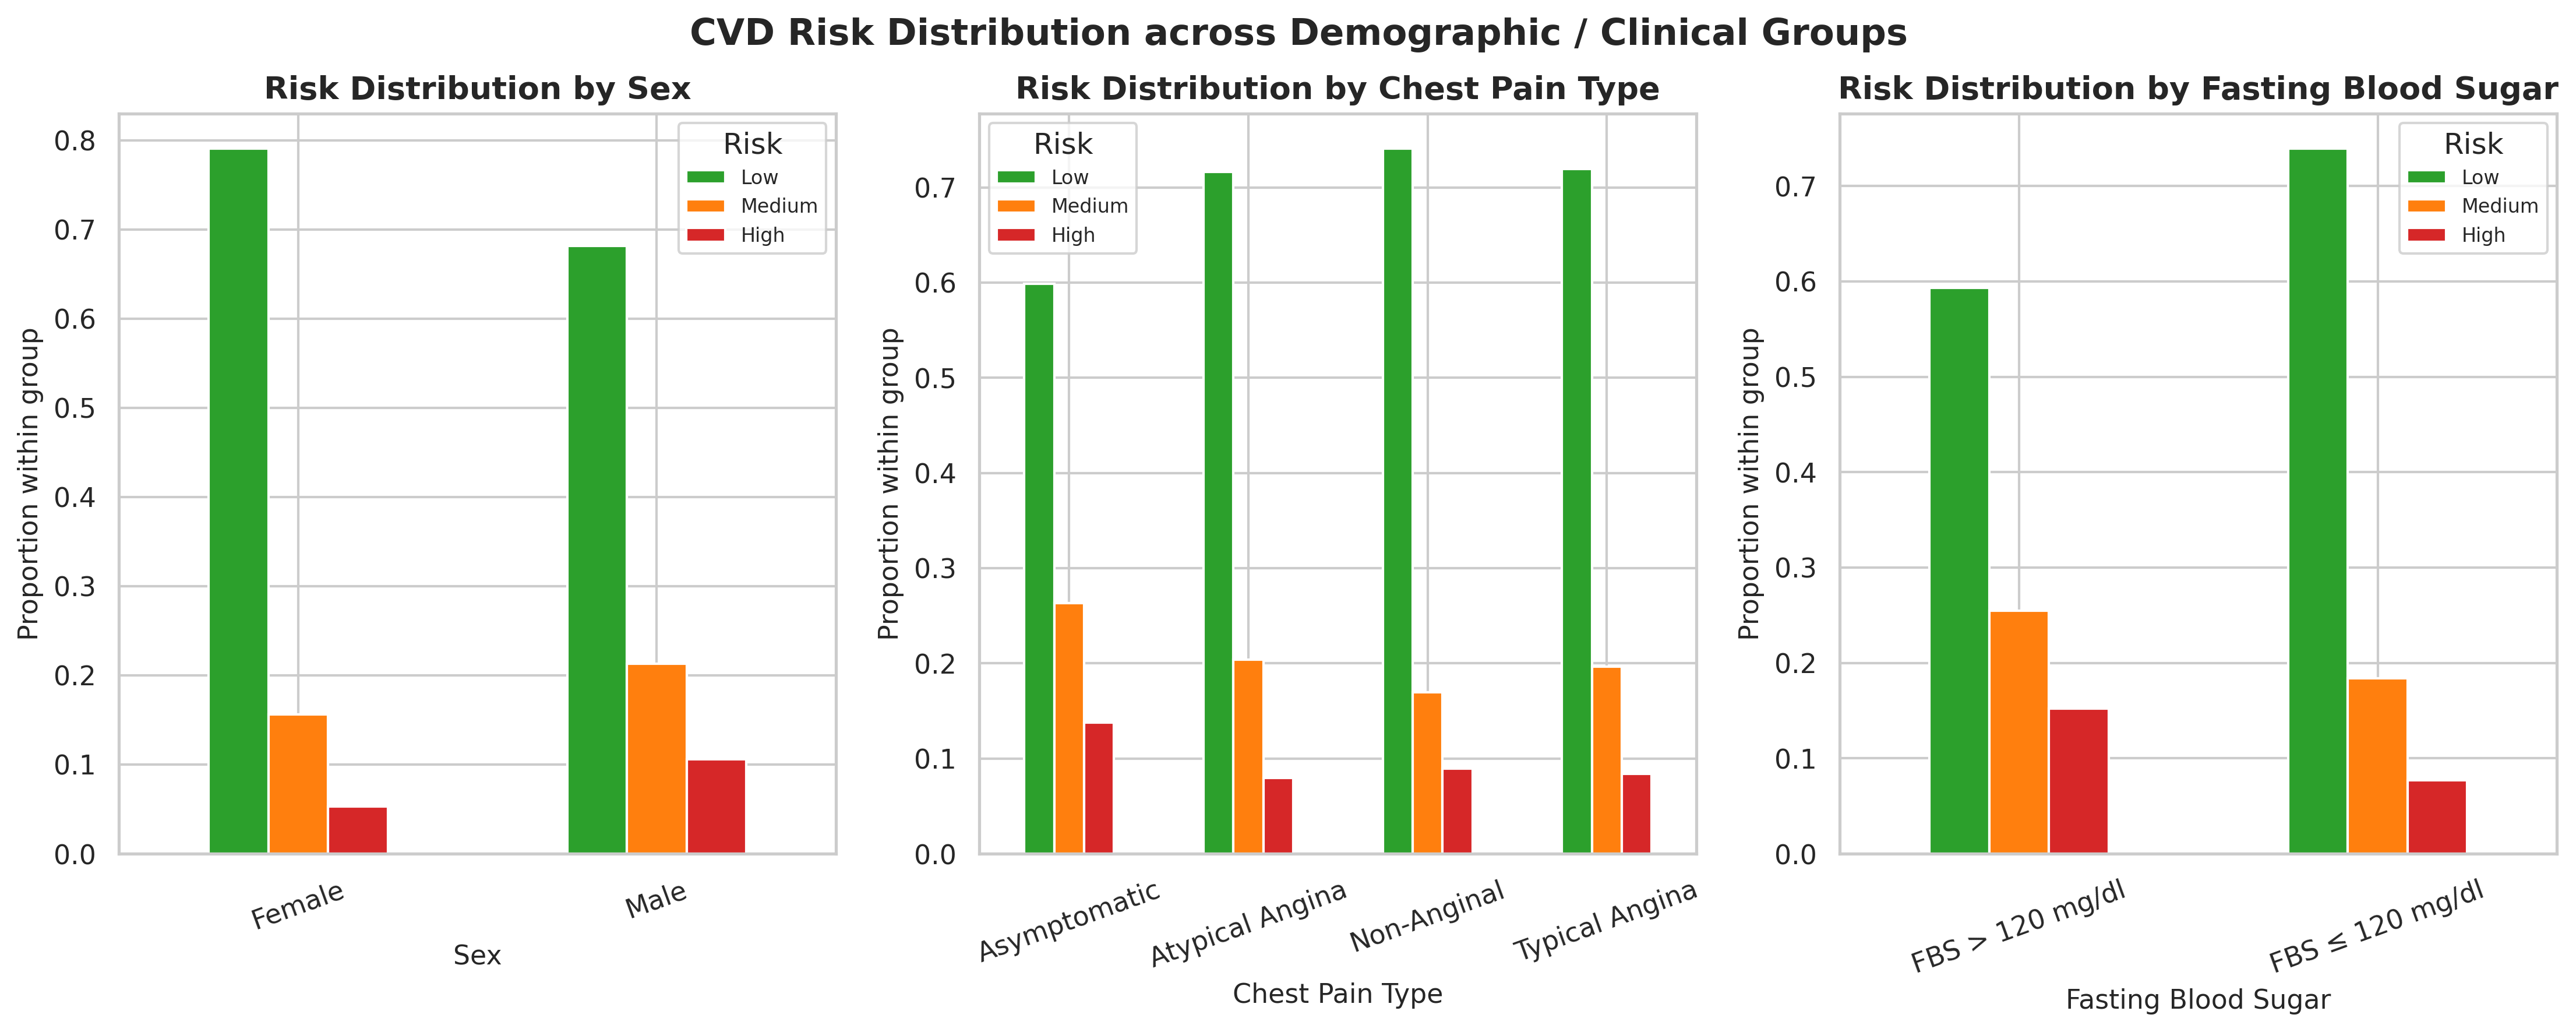

In [15]:
path = viz.plot_risk_by_demographics()
display(Image(filename=path))

### ECG / exercise-test features

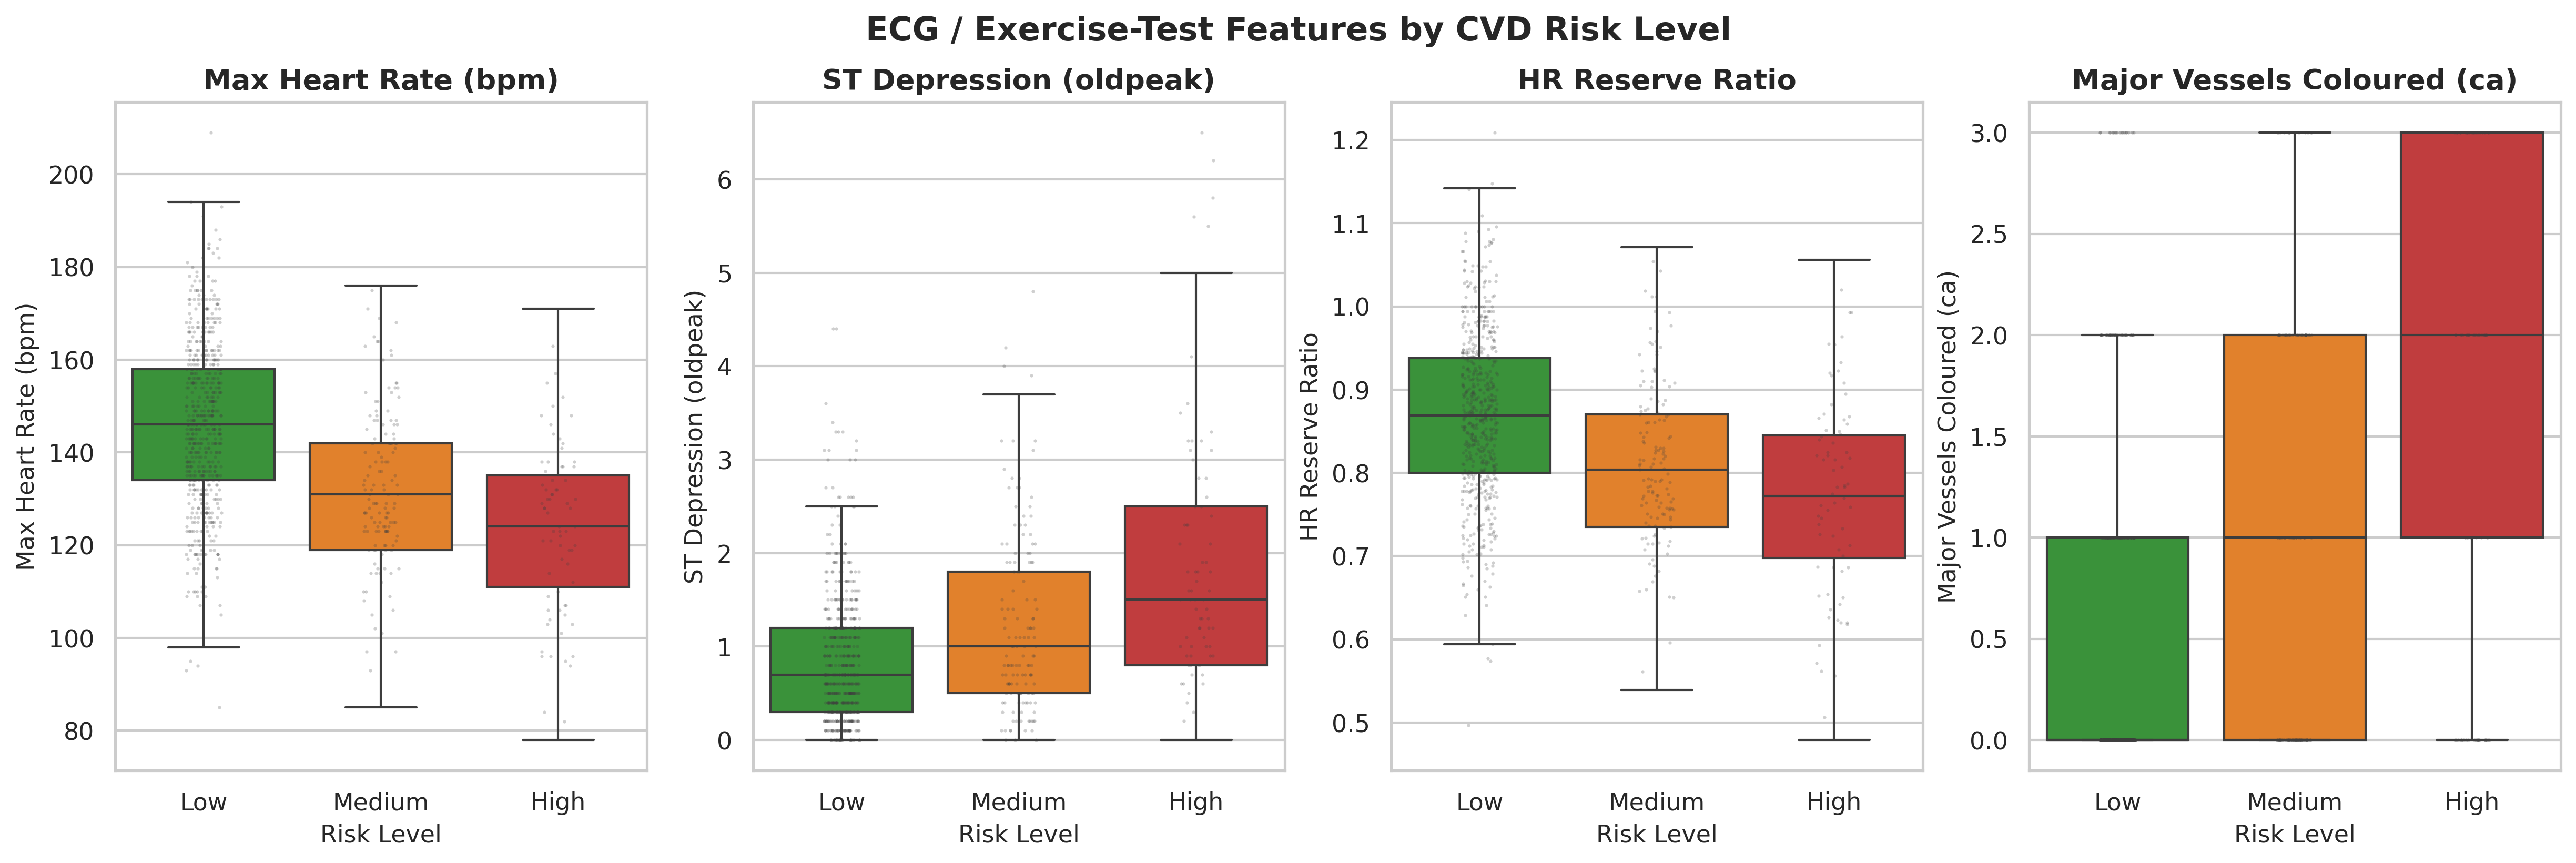

In [16]:
path = viz.plot_ecg_analysis()
display(Image(filename=path))

### ED temporal demand patterns

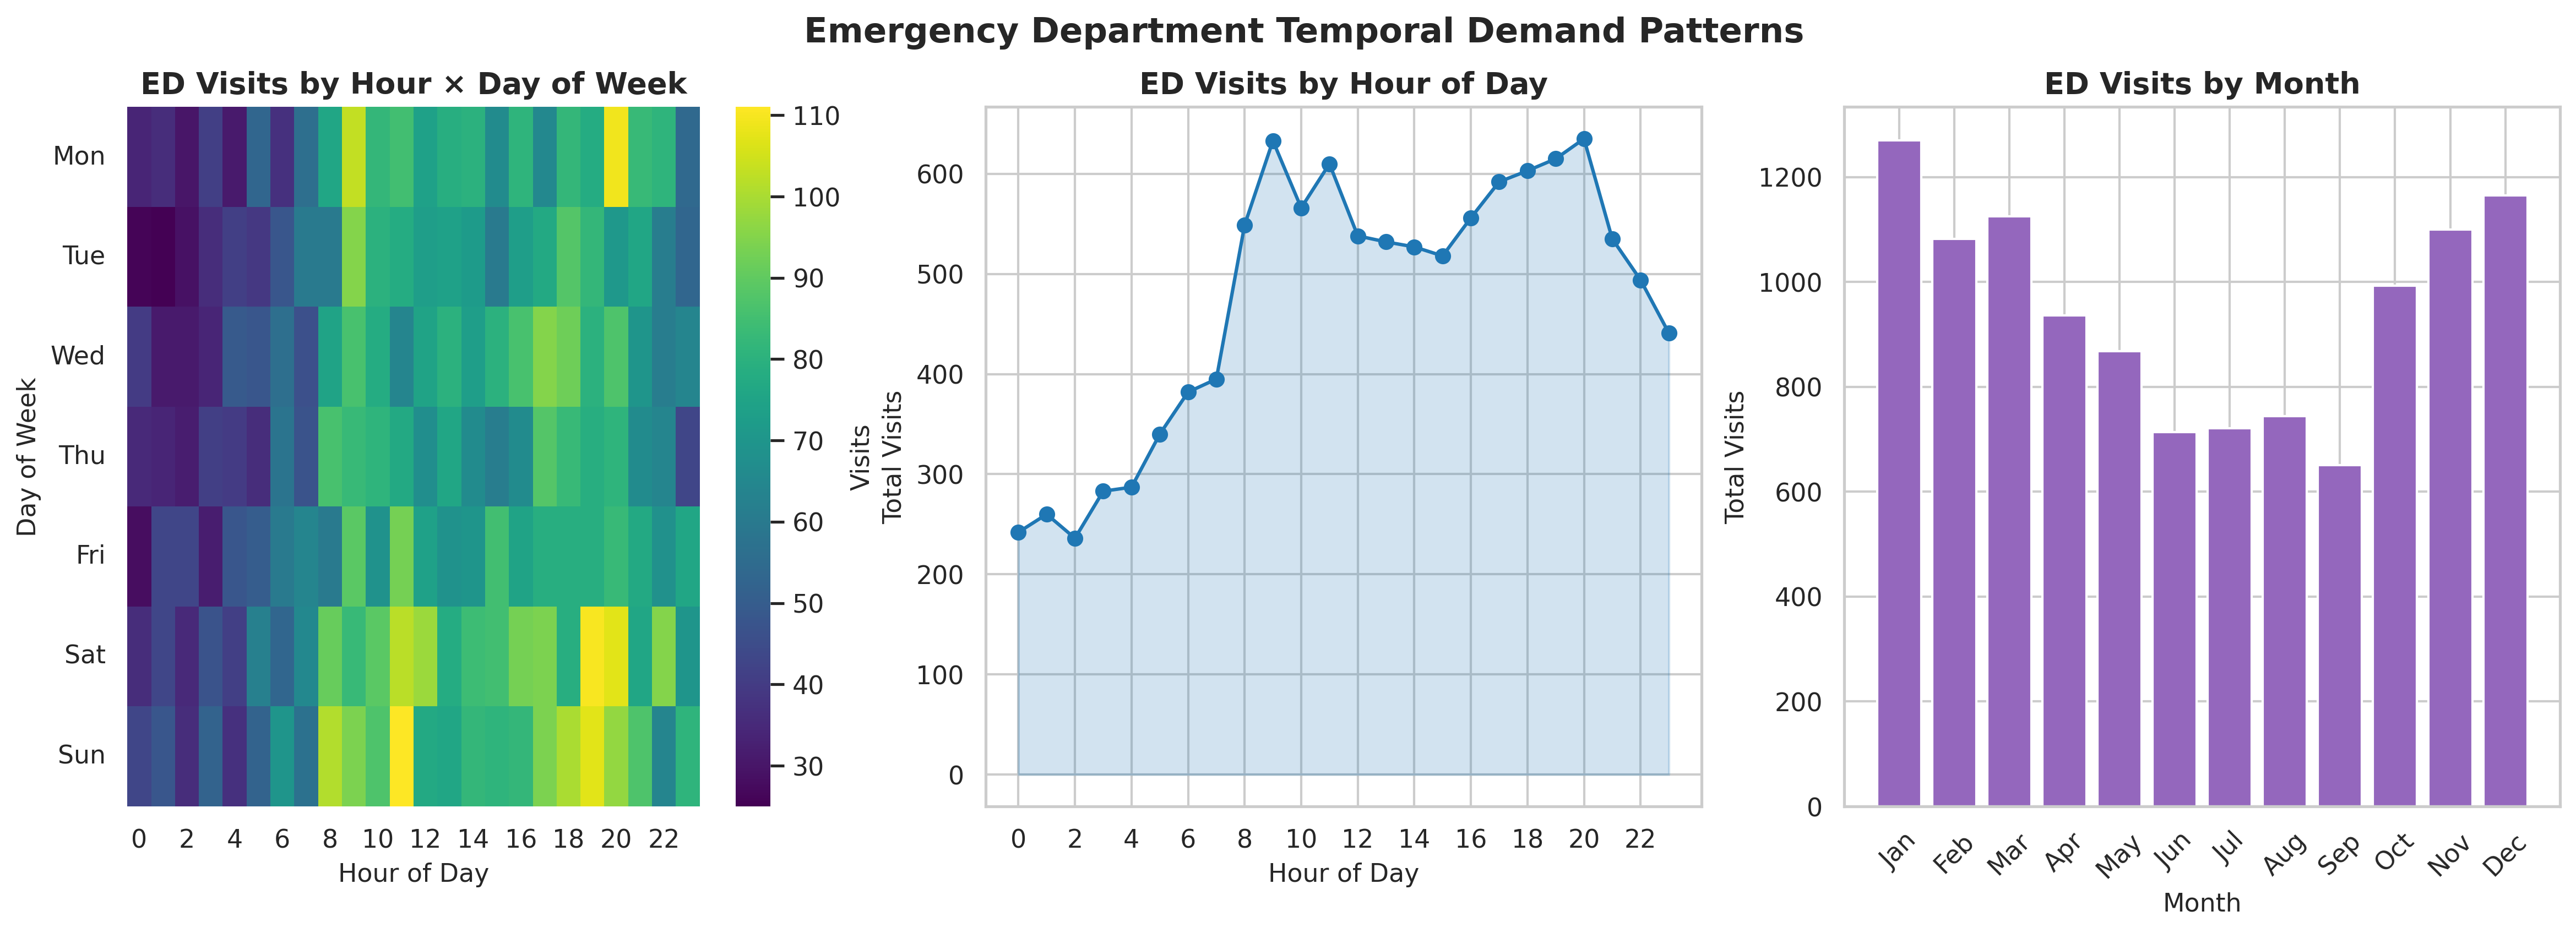

In [17]:
path = viz.plot_temporal_ed_patterns()
display(Image(filename=path))

### ED seasonal trend + rolling averages

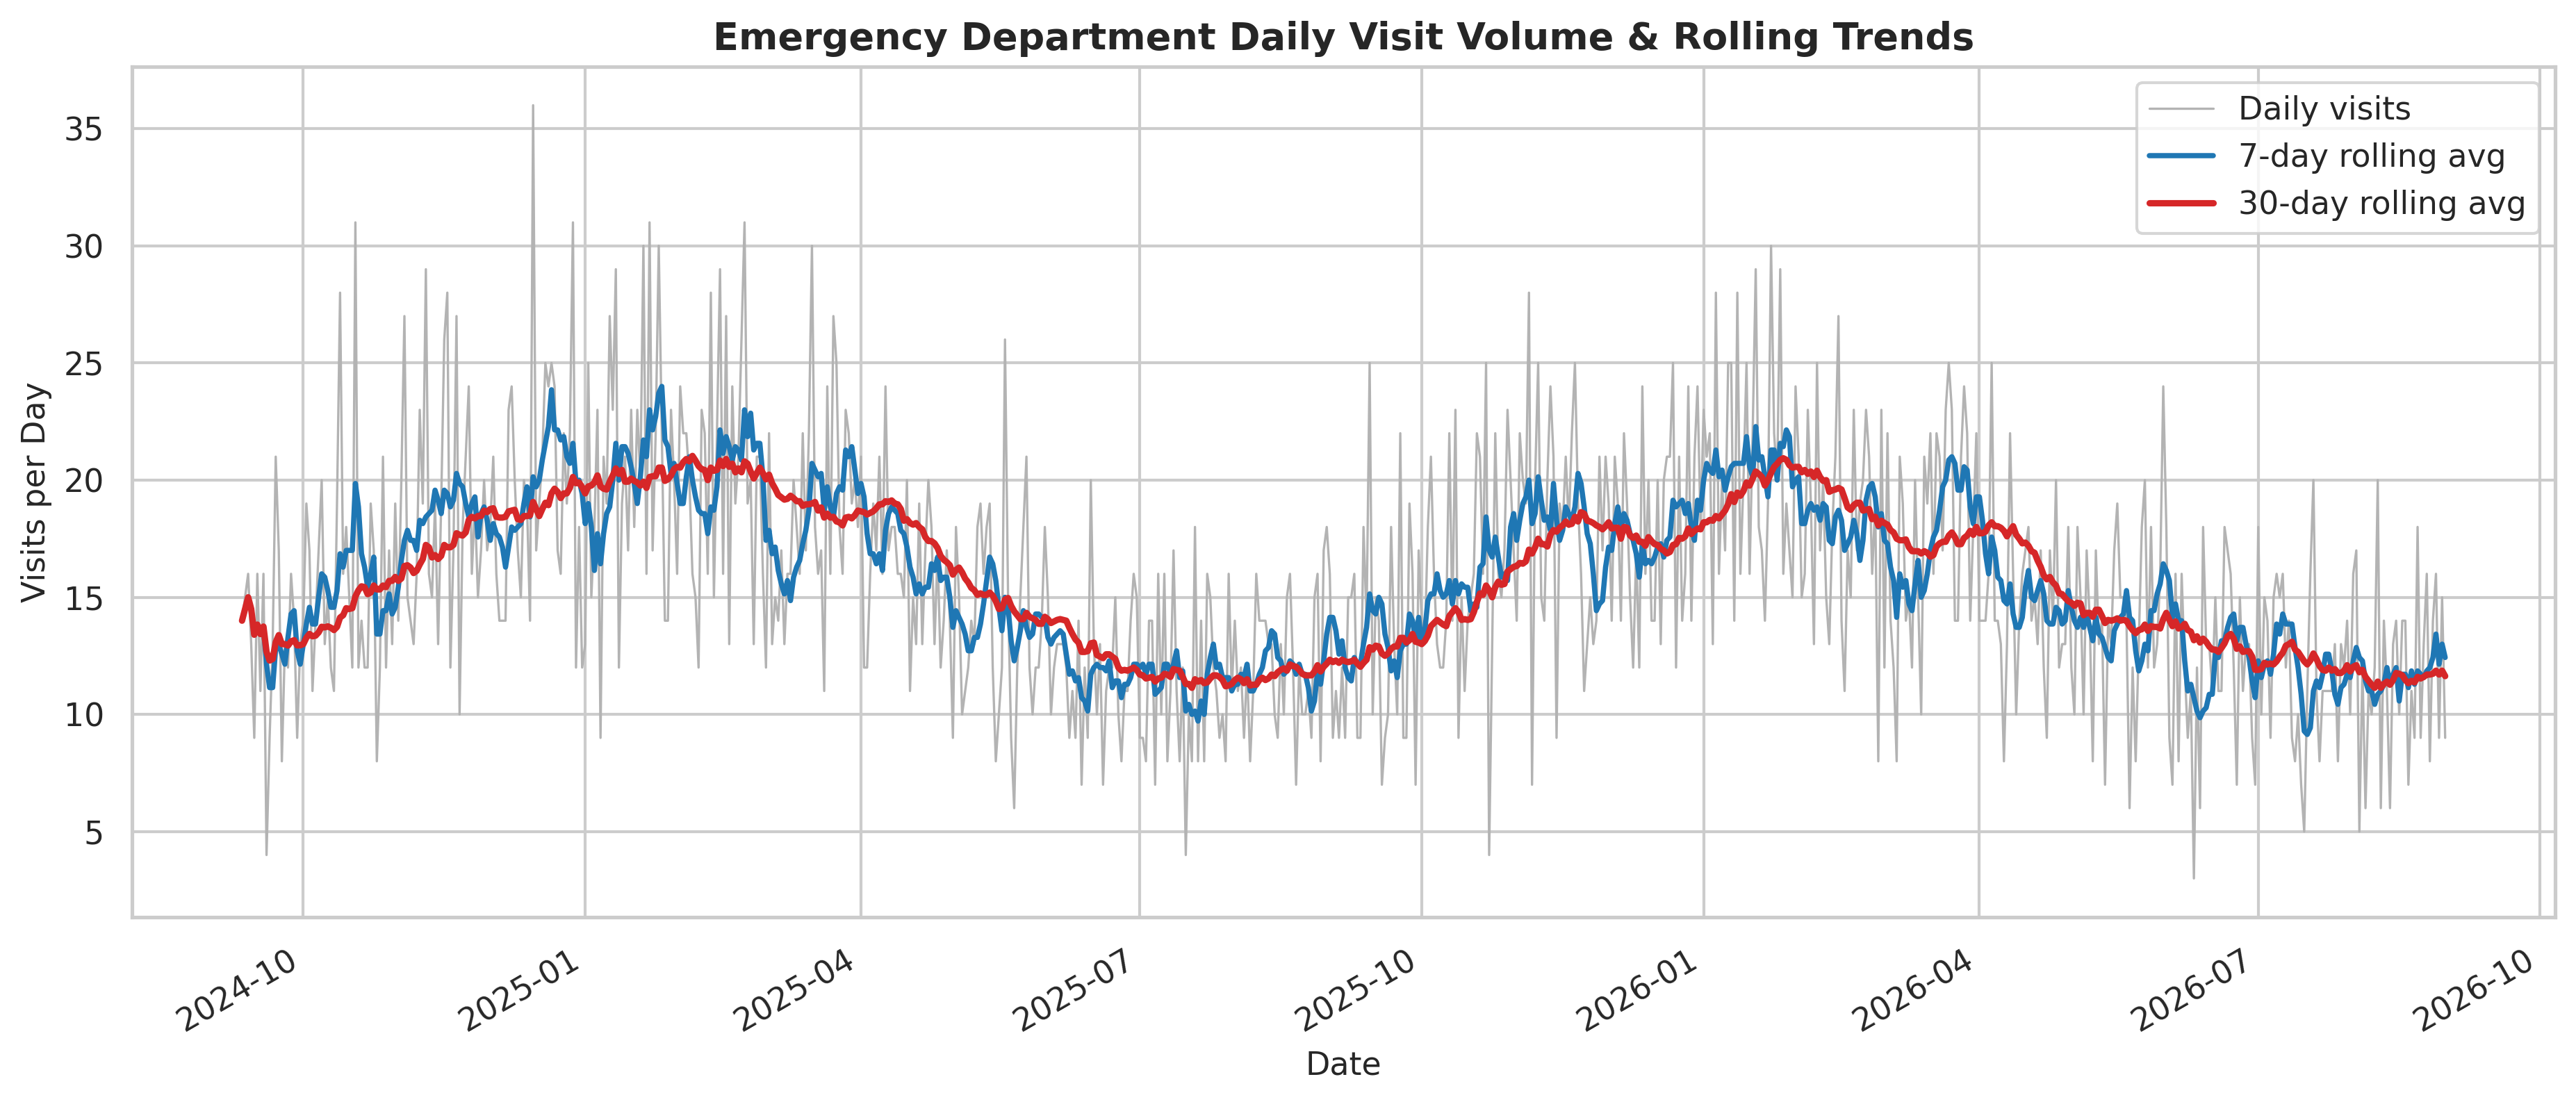

In [18]:
path = viz.plot_ed_seasonal_trends()
display(Image(filename=path))

### Cholesterol vs BP scatter

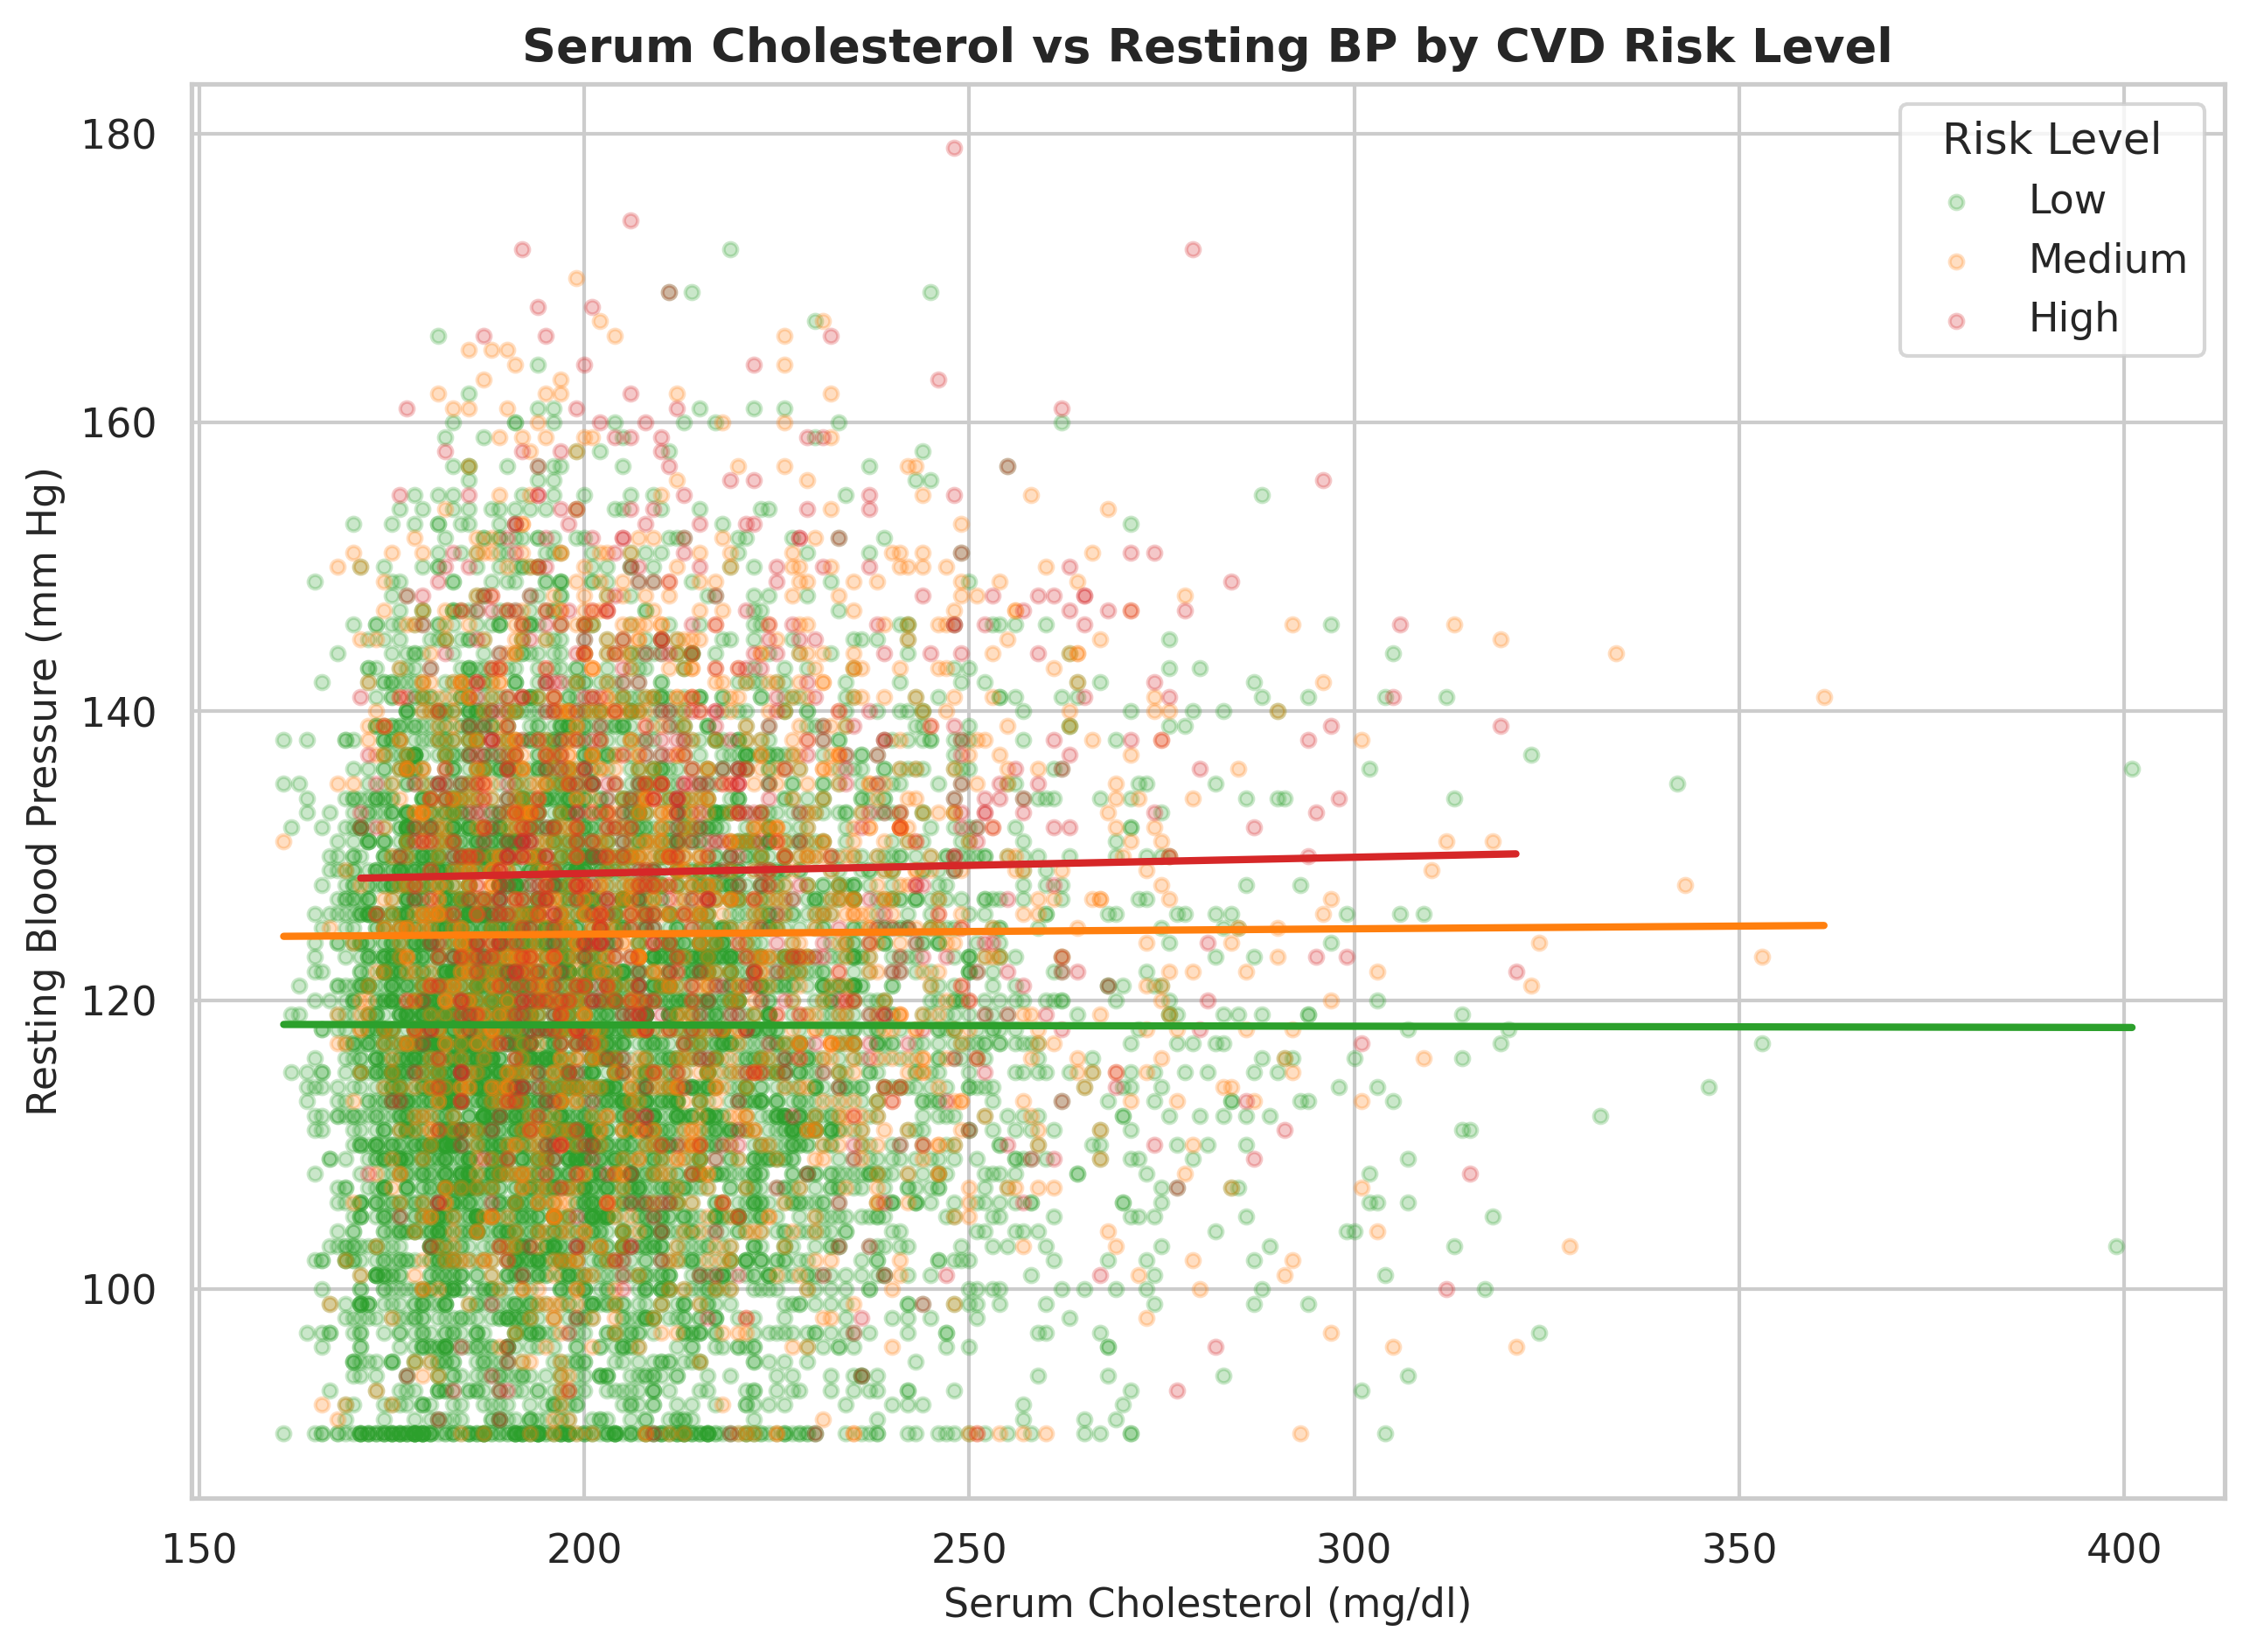

In [19]:
path = viz.plot_cholesterol_bp_scatter()
display(Image(filename=path))

### Cardiovascular risk-score distribution

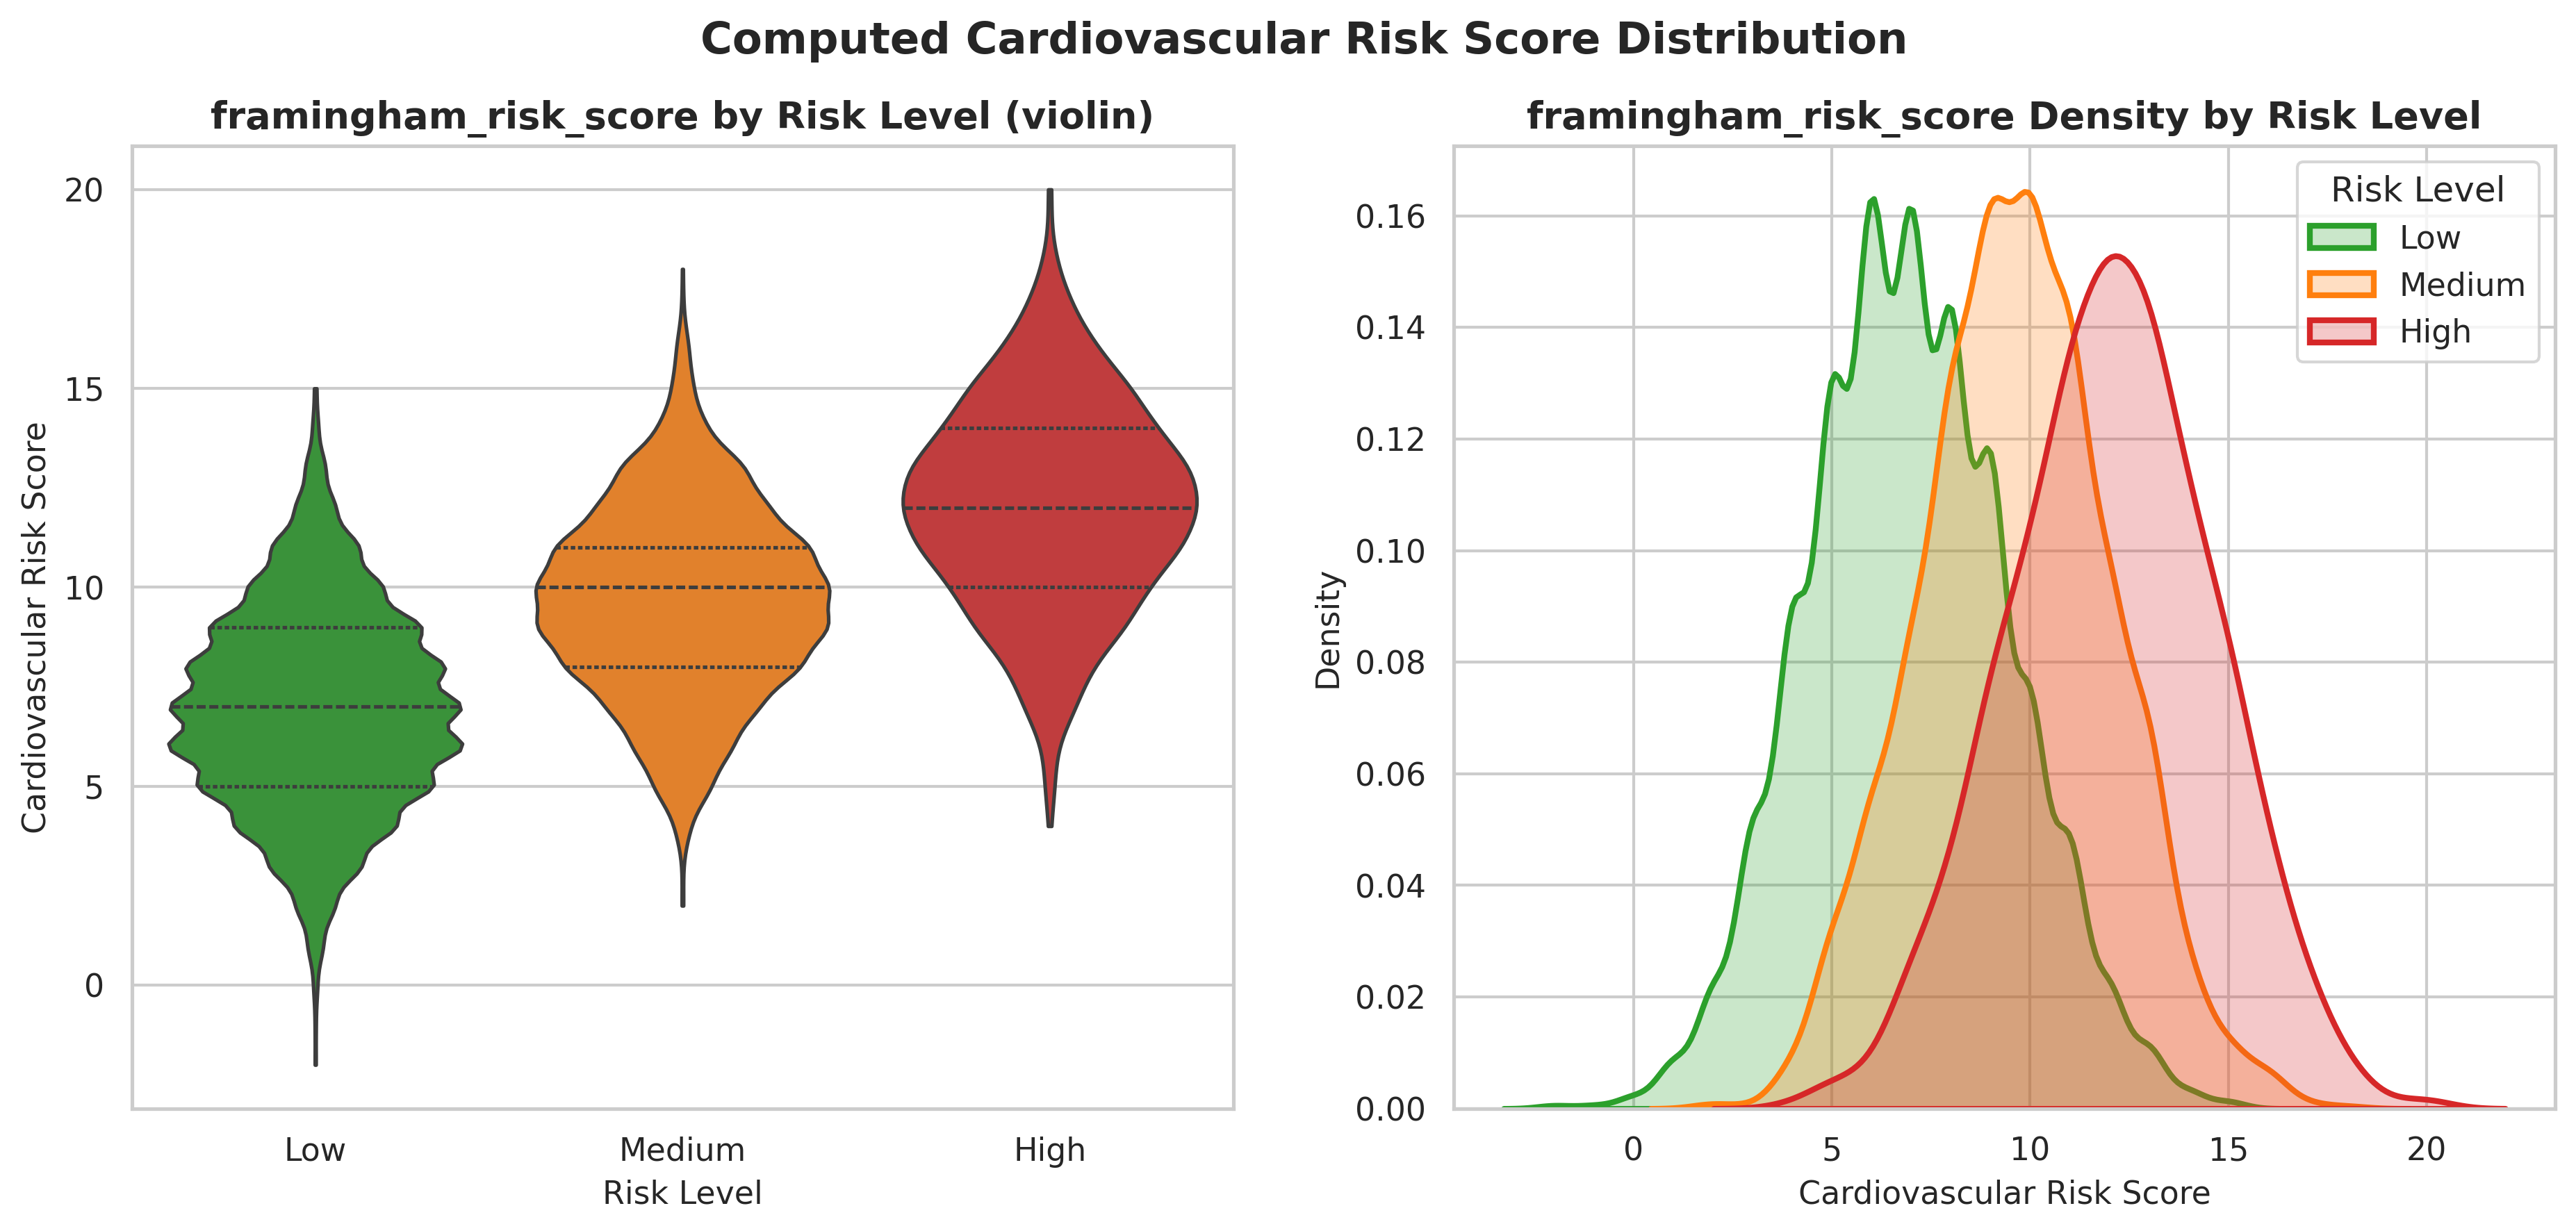

In [20]:
path = viz.plot_framingham_score_dist()
display(Image(filename=path))

## 5. Full report generation

Run the orchestrator to (re)generate every artifact and the markdown summary report.

In [21]:
from src.eda.eda_report import EDAReport

report_path = EDAReport(df).run()
print("Report written to:", report_path)


EDA complete:
  report : /home/ubuntu/github_repos/Data-Analytic-Data-Engineering/outputs/reports/eda_summary_report.md
  figures: 10 in /home/ubuntu/github_repos/Data-Analytic-Data-Engineering/outputs/figures
Report written to: /home/ubuntu/github_repos/Data-Analytic-Data-Engineering/outputs/reports/eda_summary_report.md


In [22]:
# Preview the generated markdown report
with open(report_path, encoding="utf-8") as fh:
    print(fh.read()[:3000])

# Exploratory Data Analysis — Cardiovascular Risk Stratification

*Generated: 2026-09-20 04:58*

## 1. Executive Summary

This report analyses **10,000 synthetic patient records** with 53 engineered features spanning demographics, clinical measurements, ECG / exercise-test results, computed cardiovascular risk scores, and downstream Emergency Department (ED) utilisation. The prediction target is a three-level CVD **risk stratification** (Low / Medium / High).

Risk-level breakdown: **Low** = 7,168 (71.7%); **Medium** = 1,946 (19.5%); **High** = 886 (8.9%).

## 2. Data Characteristics

- Records: **10,000**
- Total columns: **53**
- Numeric features profiled: **12**
- Total missing cells: **0** (complete dataset)

### Numeric feature summary (selected)

| feature               |   mean |   std |    min |   median |    max |   skewness |
|:----------------------|-------:|------:|-------:|---------:|-------:|-----------:|
| age                   |  53.87 |  8.71 |  30    |    54    |  80 

## 6. Summary & next steps

**Key takeaways**

1. Risk stratification is strongly driven by exercise angina, thalassemia, ST depression,
   number of major vessels, and the computed Framingham risk score.
2. Demographic patterns are clear: risk rises with age and differs by sex and chest-pain type.
3. ED demand shows pronounced hour-of-day and day-of-week seasonality — valuable for the
   capacity-planning module.

**Recommendations for modeling**

- Prefer tree-based models (XGBoost / Random Forest) given non-normal features and interactions.
- Use stratified splits and class weighting to handle mild target imbalance.
- Decide explicitly whether derived risk scores belong in the model feature set to avoid leakage.
- Feed the risk-stratification output into ED demand forecasting.